In [2]:
import os
from pathlib import Path
import random
import pandas as pd
import numpy as np
from joblib import Memory 
from collections import defaultdict
import json
from time import perf_counter
from tqdm.autonotebook import tqdm
from datetime import datetime
from itertools import count
import shutil
import re
from math import sqrt
from typing import Dict, List, Iterable, Optional
from joblib import Parallel, delayed
from sklearn.base import clone 

from sklearn.feature_selection import f_regression, mutual_info_regression
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')

from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import MultiTaskElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin            
from sklearn.metrics import mean_squared_error, r2_score

from hyperopt import hp, fmin, tpe, Trials, STATUS_OK, space_eval
from hyperopt.early_stop import no_progress_loss

C:\Users\LL331070\AppData\Local\Temp\ipykernel_30672\2514610757.py:10: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


In [2]:
# Set random seed for reproducibility
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

### Data load and preparing

In [3]:
# Load and align X with co-expression module information
X_raw = pd.read_csv("../data/features_label/processed_X/x_clean_no_scaled_no_imputation.csv", index_col=0) # Load the cleaned feature matrix without scaling
gene_to_feature = pd.read_csv("../data/features_label/co_expression_info/gene_to_feature.csv") # Load the gene to feature mapping

In [4]:
# Keep only genes that are both in X_raw and in the mapping
print(f"Original matrix shape: {X_raw.shape}")
genes_in_modules = set(
    g for g in gene_to_feature["gene"] if g in X_raw.columns
)
X_use = X_raw.loc[:, sorted(genes_in_modules)].astype("float32").copy()
print(f"Matrix shape after aligning with co-expression modules: {X_use.shape}")

Original matrix shape: (513, 18082)
Matrix shape after aligning with co-expression modules: (513, 18082)


In [5]:
# Build dictionary module -> list of genes
modules = defaultdict(list)
for g, m in gene_to_feature[gene_to_feature["gene"].isin(genes_in_modules)].values:
    modules[m].append(g)
modules = {m: sorted(gs) for m, gs in modules.items()}

print(f"Genes used: {X_use.shape[1]} | Modules: {len(modules)}")

Genes used: 18082 | Modules: 14455


In [ ]:
# extract background genes for overrepresentation analysis
# background_genes = set(X_raw.columns)
# print(f"Background genes: {len(background_genes)}")
# 
# background_genes_file = "../data/features_label/co_expression_info/background_genes.txt"
# with open(background_genes_file, "w") as f:
#     for gene in sorted(background_genes):
#         f.write(f"{gene}\n")

Background genes: 18082


Load Y labels, propensity and intensity

In [6]:
tca_status = pd.read_csv("../data/features_label/tca_status_medium.csv", index_col=0)
tca_status.head(1)

,TCA canonical,TCA non canonical,both active,biomass mean TCA no canonical,biomass mena both active,activity TCA canonical,activity TCA non canonical,NC/C,Valid_sample,Type,activity SUM NC,activity SUM C
22RV1_PROSTATE,0.1376,0.3547,84,0.076068,0.043725,2.47352,14.794442,2.577762,0.4923,PROSTATE,5.247589,0.340356


In [7]:
y_A = tca_status["TCA non canonical"].values
y_B = tca_status["activity TCA non canonical"].values
y_multi = np.vstack([y_A, y_B]).T
y = y_multi.astype("float32")

print(f"shape of y_multi: {y_multi.shape}")
assert len(y) == len(X_use)

shape of y_multi: (513, 2)


### Train ElsticNet (MultiTask)

In [8]:
outer_cv = KFold(n_splits=10, shuffle=True, random_state=SEED)  # outer CV
inner_cv = KFold(n_splits=5,  shuffle=True, random_state=SEED)  # inner CV

In [26]:
# --- FIXED-MODULE AGGREGATOR: ALWAYS PC1 ---

class FixedModuleAggregator(BaseEstimator, TransformerMixin):
    """
    Aggregate genes into one feature per module by ALWAYS keeping PC1.
    Assumes X has been z-scored upstream (fit on train only within the CV pipeline).
    """
    def __init__(self, modules, feature_names, random_state=42):
        # DO NOT transform constructor params (sklearn clone rule)
        self.modules = modules
        self.feature_names = feature_names
        self.random_state = random_state

    def fit(self, X, y=None):
        # Convert feature_names here (fit-time), not in __init__
        self.genes_ = np.array(self.feature_names, dtype=object)
        self.loadings_ = []      # list of (idx_array, components_matrix[1 x n_genes_in_module])
        self.var_exp_ = []       # PC1 variance explained per module (NaN for singletons)
        self.out_features_ = []  # one output feature per module (module name)

        for mname, g_list in self.modules.items():
            # Map gene names to column indices present in X
            idx = [np.where(self.genes_ == g)[0][0] for g in g_list if g in self.genes_]
            if not idx:
                continue
            idx = np.array(idx, dtype=int)
            Xi = X[:, idx]  # z-scored TRAIN data for this module

            if len(idx) == 1:
                # 1 gene: passthrough (no PCA)
                w = np.ones((1, 1), dtype=np.float32)
                self.loadings_.append((idx, w))
                self.var_exp_.append(np.nan)
                self.out_features_.append(mname)
                continue

            # >=2 genes: PCA with a single component (PC1)
            pca = PCA(n_components=1, svd_solver="full", random_state=self.random_state)
            pca.fit(Xi)
            comps = pca.components_.astype(np.float32)      # (1 × n_genes_in_module)
            var1 = float(pca.explained_variance_ratio_[0])

            # Sign anchoring to align PC1 with module mean
            pc1_scores = Xi @ comps.T
            mean_signal = Xi.mean(axis=1, keepdims=True)
            corr = np.corrcoef(pc1_scores.ravel(), mean_signal.ravel())[0, 1]
            if np.isfinite(corr) and corr < 0:
                comps *= -1.0

            self.loadings_.append((idx, comps))
            self.var_exp_.append(var1)
            self.out_features_.append(mname)

        self.out_features_ = np.array(self.out_features_, dtype=object)
        return self

    def transform(self, X):
        blocks = []
        for (idx, comps) in self.loadings_:
            Xi = X[:, idx]
            scores = Xi @ comps.T
            blocks.append(scores.astype(np.float32))
        if not blocks:
            return np.empty((X.shape[0], 0), dtype=np.float32)
        return np.hstack(blocks)

    def get_feature_names_out(self, input_features=None):
        return self.out_features_


In [24]:
# BUILD PIPELINE: scale X -> aggregate modules (PC1) -> MultiTask Elastic Net-
def make_pipeline(modules, feature_names, seed=42):
    pipe = Pipeline(steps=[
        ("scale_x", StandardScaler(with_mean=True, with_std=True)),
        ("agg", FixedModuleAggregator(modules=modules,
                                      feature_names=list(feature_names),  # <- pass-through, no transform
                                      random_state=seed)),
        ("model", MultiTaskElasticNet(random_state=seed, max_iter=10000, tol=1e-6))
    ])
    return pipe

In [27]:
# function without pallelism for outer CV
def nested_cv_mt_en(X_df: pd.DataFrame,
                    y_mat: np.ndarray,
                    modules: dict,
                    outer_cv,
                    inner_cv,
                    optimizer: str = "hyperopt",           # "hyperopt" or "grid"
                    param_grid: dict | None = None,        # used if optimizer="grid"
                    hyperopt_evals: int = 100,             # used if optimizer="hyperopt"
                    early_stopping_rounds: int = 30,       # for hyperopt
                    hyperopt_space: dict | None = None,    # custom Hyperopt space
                    n_jobs_inner: int = -1,                # parallelism for inner CV
                    verbose: bool = True,                  # print per-fold reports
                    print_hyperopt_every: int = 1,         # print every k hyperopt trials
                    print_train_metrics: bool = True,      # print train metrics per fold
                    use_one_se: bool = False,              #  enable 1-SE model selection
                    prefer_stronger_in_1se: bool = False,   # tie-break towards larger alpha, lower l1
                    use_tqdm: bool = True,                 # progress bar on outer CV
                    error_score='raise',                   # pass-through to cross_val_score
                    outdir: Path = Path("./mt_en_results"),
                    seed: int = 42):
    """
    Nested CV for MultiTask Elastic Net with module-level PC1 aggregation (no caching),
    with detailed runtime logging.

    New options:
      - use_one_se: if True, apply the 1-SE rule on inner-CV results to pick a simpler model.
      - prefer_stronger_in_1se: if True and use_one_se is True, among 1-SE candidates
        pick the one with larger alpha (more shrinkage), then smaller l1_ratio (more ridge-ish).
    """
    # --- local imports ---
    from math import sqrt
    if optimizer == "hyperopt":
        from hyperopt import fmin, tpe, hp, Trials, STATUS_OK
        from hyperopt.early_stop import no_progress_loss

    outdir.mkdir(parents=True, exist_ok=True)
    metrics_rows = []

    # ----- tiny logger that plays well with tqdm -----
    def _ts(): return datetime.now().strftime("%H:%M:%S")
    def _log(msg):
        if verbose:
            (tqdm.write if use_tqdm else print)(f"[{_ts()}] {msg}")

    # ----- dataset/module overview -----
    X = X_df.values.astype(np.float32)
    n_samples, n_genes = X.shape
    all_mod_genes = {g for gs in modules.values() for g in gs}
    missing = sorted(list(all_mod_genes - set(X_df.columns)))
    _log(f"Dataset: samples={n_samples}, genes={n_genes}; modules={len(modules)}; "
         f"module-genes total={len(all_mod_genes)}, missing_in_X={len(missing)}")
    if missing:
        _log("Warning: alcuni geni dei moduli non sono in X e verranno ignorati.")

    # ----- default grid if needed -----
    if param_grid is None:
        param_grid = {
            "model__alpha": np.logspace(-6, -1, 8),
            "model__l1_ratio": np.linspace(0.0, 1.0, 11)
        }

    # ----- outer loop -----
    n_folds = outer_cv.get_n_splits(X)
    fold_iter = list(outer_cv.split(X))
    if use_tqdm:
        fold_iter = tqdm(fold_iter, total=n_folds, desc="Outer CV", leave=True)

    fold_id = 0
    for tr_idx, te_idx in fold_iter:
        fold_id += 1
        t0 = perf_counter()
        _log(f"Fold {fold_id}/{n_folds} — train={len(tr_idx)}, test={len(te_idx)}, optimizer={optimizer}")

        X_tr, X_te = X[tr_idx], X[te_idx]
        y_tr, y_te = y_mat[tr_idx], y_mat[te_idx]

        # y standardization on TRAIN only
        y_scaler = StandardScaler(with_mean=True, with_std=True)
        y_tr_z = y_scaler.fit_transform(y_tr)
        y_te_z = y_scaler.transform(y_te)

        # build fresh pipeline
        pipe = make_pipeline(modules=modules, feature_names=X_df.columns, seed=seed)

        # ----- inner search -----
        if optimizer == "hyperopt":
            # Search space: use provided or default
            space = (hyperopt_space if hyperopt_space is not None else {
                "alpha": hp.loguniform("alpha", np.log(1e-6), np.log(1e-1)),
                "l1_ratio": hp.uniform("l1_ratio", 0.0, 1.0)
            })

            trial_counter = count(0)
            best_so_far = {"loss": np.inf, "alpha": None, "l1_ratio": None}

            def obj(params):
                """Return mean inner-CV MSE and its SEM for 1-SE selection."""
                k = next(trial_counter) + 1
                pipe.set_params(model__alpha=float(params["alpha"]),
                                model__l1_ratio=float(params["l1_ratio"]))
                # per-fold MSEs
                fold_mse = -cross_val_score(
                    pipe, X_tr, y_tr_z,
                    cv=inner_cv, scoring="neg_mean_squared_error",
                    n_jobs=n_jobs_inner, error_score=error_score
                )
                loss_mean = float(fold_mse.mean())
                loss_sem  = float(fold_mse.std(ddof=1) / sqrt(inner_cv.get_n_splits()))
                if loss_mean < best_so_far["loss"]:
                    best_so_far.update(loss=loss_mean,
                                       alpha=float(params["alpha"]),
                                       l1_ratio=float(params["l1_ratio"]))
                    _log(f"  [fold {fold_id}] new best @eval {k}: MSE={loss_mean:.6f} "
                         f"| alpha={best_so_far['alpha']:.3e} | l1={best_so_far['l1_ratio']:.2f}")
                elif (k % max(1, print_hyperopt_every)) == 0:
                    _log(f"  [fold {fold_id}] eval {k}: MSE={loss_mean:.6f} "
                         f"| alpha={float(params['alpha']):.3e} | l1={float(params['l1_ratio']):.2f}")
                # store SEM and params so we can apply 1-SE afterwards
                return {"loss": loss_mean, "status": STATUS_OK,
                        "loss_sem": loss_sem,
                        "alpha": float(params["alpha"]),
                        "l1_ratio": float(params["l1_ratio"])}

            _log(f"  Hyperopt: max_evals={hyperopt_evals}, early_stop={early_stopping_rounds}, inner_n_jobs={n_jobs_inner}")
            trials = Trials()
            fmin(fn=obj, space=space, algo=tpe.suggest,
                 max_evals=int(hyperopt_evals),
                 early_stop_fn=no_progress_loss(int(early_stopping_rounds)),
                 rstate=np.random.default_rng(seed),
                 trials=trials, show_progressbar=True)

            # Build results table from trials
            rows = []
            for tr in trials.trials:
                res = tr["result"]
                if ("loss" in res) and np.isfinite(res["loss"]):
                    rows.append({"loss": float(res["loss"]),
                                 "loss_sem": float(res.get("loss_sem", np.nan)),
                                 "alpha": float(res.get("alpha", np.nan)),
                                 "l1_ratio": float(res.get("l1_ratio", np.nan))})
            res_df = pd.DataFrame(rows).dropna()
            assert len(res_df) > 0, "Hyperopt produced no valid trials."

            # Select best params:
            # - If use_one_se: 1-SE rule (threshold = best_loss + best_sem), then prefer stronger shrinkage
            # - Else: pick the absolute minimum loss
            if use_one_se:
                best_row = res_df.loc[res_df["loss"].idxmin()]
                thr = best_row["loss"] + best_row["loss_sem"]  # 1-SE threshold
                cands = res_df[res_df["loss"] <= thr].copy()
                if prefer_stronger_in_1se:
                    cands.sort_values(by=["alpha", "l1_ratio"], ascending=[False, True], inplace=True)
                else:
                    cands.sort_values(by=["loss"], ascending=True, inplace=True)
                chosen = cands.iloc[0]
                _log(f"  1-SE pick: MSE={chosen['loss']:.6f} (<= {thr:.6f}) | "
                     f"alpha={chosen['alpha']:.3e} | l1={chosen['l1_ratio']:.2f}")
            else:
                chosen = res_df.loc[res_df["loss"].idxmin()]
                _log(f"  Best inner-CV (min MSE): {chosen['loss']:.6f} | "
                     f"alpha={chosen['alpha']:.3e} | l1={chosen['l1_ratio']:.2f}")

            best_params = {"model__alpha": float(chosen["alpha"]),
                           "model__l1_ratio": float(chosen["l1_ratio"])}
            inner_best_mse = float(chosen["loss"])

        else:
            # Manual grid with per-combo SEM so we can also apply 1-SE if requested
            _log(f"  Grid search: {len(param_grid['model__alpha'])}×{len(param_grid['model__l1_ratio'])} combos, "
                 f"inner_n_jobs={n_jobs_inner}")
            rows = []
            n_done = 0
            for alpha in param_grid["model__alpha"]:
                for l1 in param_grid["model__l1_ratio"]:
                    pipe.set_params(model__alpha=float(alpha), model__l1_ratio=float(l1))
                    fold_mse = -cross_val_score(
                        pipe, X_tr, y_tr_z,
                        cv=inner_cv, scoring="neg_mean_squared_error",
                        n_jobs=n_jobs_inner, error_score=error_score
                    )
                    score_mean = float(fold_mse.mean())
                    score_sem  = float(fold_mse.std(ddof=1) / sqrt(inner_cv.get_n_splits()))
                    n_done += 1
                    rows.append({"loss": score_mean, "loss_sem": score_sem,
                                 "alpha": float(alpha), "l1_ratio": float(l1)})
                    _log(f"  [fold {fold_id}] grid {n_done}: MSE={score_mean:.6f} "
                         f"| alpha={alpha:.3e} | l1={l1:.2f}")
            res_df = pd.DataFrame(rows)

            if use_one_se:
                best_row = res_df.loc[res_df["loss"].idxmin()]
                thr = best_row["loss"] + best_row["loss_sem"]
                cands = res_df[res_df["loss"] <= thr].copy()
                if prefer_stronger_in_1se:
                    cands.sort_values(by=["alpha", "l1_ratio"], ascending=[False, True], inplace=True)
                else:
                    cands.sort_values(by=["loss"], ascending=True, inplace=True)
                chosen = cands.iloc[0]
                _log(f"  1-SE pick: MSE={chosen['loss']:.6f} (<= {thr:.6f}) | "
                     f"alpha={chosen['alpha']:.3e} | l1={chosen['l1_ratio']:.2f}")
            else:
                chosen = res_df.loc[res_df["loss"].idxmin()]
                _log(f"  Best inner-CV (min MSE): {chosen['loss']:.6f} | "
                     f"alpha={chosen['alpha']:.3e} | l1={chosen['l1_ratio']:.2f}")

            best_params = {"model__alpha": float(chosen["alpha"]),
                           "model__l1_ratio": float(chosen["l1_ratio"])}
            inner_best_mse = float(chosen["loss"])

        _log(f"  Best inner-CV: MSE={inner_best_mse:.6f} | "
             f"alpha={best_params['model__alpha']:.3e} | l1={best_params['model__l1_ratio']:.2f}")

        # ----- fit on TRAIN with best params -----
        t_fit = perf_counter()
        pipe.set_params(**best_params)
        pipe.fit(X_tr, y_tr_z)
        fit_time = perf_counter() - t_fit

        # ----- quick info on aggregated features -----
        agg_names = pipe.named_steps["agg"].get_feature_names_out()
        _log(f"  Aggregated features: {len(agg_names)} (from {X_df.shape[1]} genes); fit_time={fit_time:.1f}s")

        # Predict
        yhat_tr_z = pipe.predict(X_tr)
        yhat_te_z = pipe.predict(X_te)
        yhat_tr   = y_scaler.inverse_transform(yhat_tr_z)
        yhat_te   = y_scaler.inverse_transform(yhat_te_z)

        # Metrics helper
        def eval_block(y_true, y_pred, split, scale_tag):
            rows = []
            for j, tgt in enumerate(["A", "B"]):
                r2  = r2_score(y_true[:, j], y_pred[:, j])
                mse = mean_squared_error(y_true[:, j], y_pred[:, j])
                rows.append({"fold": fold_id, "split": split, "target": tgt, "scale": scale_tag,
                             "R2": r2, "MSE": mse, "RMSE": np.sqrt(mse),
                             "alpha": best_params["model__alpha"], "l1_ratio": best_params["model__l1_ratio"],
                             "n_samples": y_true.shape[0]})
            r2_macro  = np.mean([rows[-2]["R2"], rows[-1]["R2"]])
            mse_macro = np.mean([rows[-2]["MSE"], rows[-1]["MSE"]])
            rows.append({"fold": fold_id, "split": split, "target": "avg", "scale": scale_tag,
                         "R2": r2_macro, "MSE": mse_macro, "RMSE": np.sqrt(mse_macro),
                         "alpha": best_params["model__alpha"], "l1_ratio": best_params["model__l1_ratio"],
                         "n_samples": y_true.shape[0]})
            return rows

        # Collect metrics
        metrics_rows += eval_block(y_tr_z, yhat_tr_z, "train", "standardized")
        metrics_rows += eval_block(y_te_z, yhat_te_z, "test",  "standardized")
        metrics_rows += eval_block(y_tr,   yhat_tr,   "train", "original")
        metrics_rows += eval_block(y_te,   yhat_te,   "test",  "original")

        # Quick train/test report (original scale)
        test_A_r2  = r2_score(y_te[:, 0], yhat_te[:, 0]);  test_A_mse  = mean_squared_error(y_te[:, 0], yhat_te[:, 0])
        test_B_r2  = r2_score(y_te[:, 1], yhat_te[:, 1]);  test_B_mse  = mean_squared_error(y_te[:, 1], yhat_te[:, 1])
        test_avg_r2   = 0.5 * (test_A_r2 + test_B_r2)
        test_avg_rmse = np.sqrt(0.5 * (test_A_mse + test_B_mse))

        if print_train_metrics:
            train_A_r2 = r2_score(y_tr[:, 0], yhat_tr[:, 0]); train_A_mse = mean_squared_error(y_tr[:, 0], yhat_tr[:, 0])
            train_B_r2 = r2_score(y_tr[:, 1], yhat_tr[:, 1]); train_B_mse = mean_squared_error(y_tr[:, 1], yhat_tr[:, 1])
            train_avg_r2   = 0.5 * (train_A_r2 + train_B_r2)
            train_avg_rmse = np.sqrt(0.5 * (train_A_mse + train_B_mse))
            _log(f"  TRAIN (orig): R2[A]={train_A_r2:.3f} | R2[B]={train_B_r2:.3f} | R2[avg]={train_avg_r2:.3f} | "
                 f"RMSE[A]={np.sqrt(train_A_mse):.4f} | RMSE[B]={np.sqrt(train_B_mse):.4f} | RMSE[avg]={train_avg_rmse:.4f}")

        _log(f"  TEST  (orig): R2[A]={test_A_r2:.3f} | R2[B]={test_B_r2:.3f} | R2[avg]={test_avg_r2:.3f} | "
             f"RMSE[A]={np.sqrt(test_A_mse):.4f} | RMSE[B]={np.sqrt(test_B_mse):.4f} | RMSE[avg]={test_avg_rmse:.4f}")

        # Save CSVs
        pd.DataFrame({
            "sample_id": X_df.index[tr_idx],
            "y_true_A": y_tr[:, 0], "y_pred_A": yhat_tr[:, 0], "resid_A": y_tr[:, 0] - yhat_tr[:, 0],
            "y_true_B": y_tr[:, 1], "y_pred_B": yhat_tr[:, 1], "resid_B": y_tr[:, 1] - yhat_tr[:, 1],
        }).to_csv(outdir / f"predictions_fold_{fold_id}_train.csv", index=False)

        pd.DataFrame({
            "sample_id": X_df.index[te_idx],
            "y_true_A": y_te[:, 0], "y_pred_A": yhat_te[:, 0], "resid_A": y_te[:, 0] - yhat_te[:, 0],
            "y_true_B": y_te[:, 1], "y_pred_B": yhat_te[:, 1], "resid_B": y_te[:, 1] - yhat_te[:, 1],
        }).to_csv(outdir / f"predictions_fold_{fold_id}_test.csv", index=False)

        coefs = pipe.named_steps["model"].coef_
        coefs_df = pd.DataFrame(coefs.T, index=agg_names, columns=["coef_A", "coef_B"])
        coefs_df["coef_norm"] = np.sqrt(coefs_df["coef_A"]**2 + coefs_df["coef_B"]**2)
        coefs_df["selected"]  = (coefs_df["coef_norm"] > 0).astype(int)
        coefs_df.to_csv(outdir / f"coefs_fold_{fold_id}.csv")

        meta = {
            "fold": fold_id, "seed": seed, "optimizer": optimizer,
            "use_one_se": use_one_se, "prefer_stronger_in_1se": prefer_stronger_in_1se,
            "best_params": best_params, "inner_best_mse": inner_best_mse,
            "n_train": int(len(tr_idx)), "n_test": int(len(te_idx)),
            "n_features_in": int(X_df.shape[1]), "n_features_agg": int(len(agg_names)),
        }
        with open(outdir / f"metadata_fold_{fold_id}.json", "w") as f:
            json.dump(meta, f, indent=2)

        _log(f"  Saved: predictions/coefs/metadata for fold {fold_id} | fold_time={perf_counter()-t0:.1f}s")

    # Save metrics and summary
    metrics_df = pd.DataFrame(metrics_rows)
    metrics_df.to_csv(outdir / "metrics_all_folds.csv", index=False)
    test_orig = metrics_df.query("split=='test' and scale=='original'")
    summary = (test_orig.groupby(["target"], as_index=False)
               .agg(R2_mean=("R2", "mean"), R2_sd=("R2", "std"),
                    RMSE_mean=("RMSE", "mean"), RMSE_sd=("RMSE", "std"),
                    MSE_mean=("MSE", "mean"), MSE_sd=("MSE", "std")))
    summary.to_csv(outdir / "metrics_summary_test_original.csv", index=False)

    _log("=== Summary on TEST (original scale) ===")
    if verbose:
        tqdm.write(str(summary))

    return metrics_df, summary


In [28]:
from joblib import Parallel, delayed
from threadpoolctl import threadpool_limits
# parallel_outer: if True, parallelize the OUTER CV (joblib); else inner CV
def nested_cv_mt_en_p_outer(X_df: pd.DataFrame,
                    y_mat: np.ndarray,
                    modules: dict,
                    outer_cv,
                    inner_cv,
                    optimizer: str = "hyperopt",           # "hyperopt" or "grid"
                    param_grid: dict | None = None,        # used if optimizer="grid"
                    hyperopt_evals: int = 100,             # used if optimizer="hyperopt"
                    early_stopping_rounds: int = 30,       # for hyperopt
                    hyperopt_space: dict | None = None,    # custom Hyperopt space
                    n_jobs_inner: int = 1,                 # inner CV jobs (set 1 when outer is parallel)
                    verbose: bool = True,                  # print per-fold reports
                    print_hyperopt_every: int = 1,         # print every k hyperopt trials
                    print_train_metrics: bool = True,      # print train metrics per fold
                    use_one_se: bool = False,              # enable 1-SE rule
                    prefer_stronger_in_1se: bool = False,  # tie-break: larger alpha, lower l1
                    use_tqdm: bool = True,                 # progress bar (only affects logs)
                    error_score='raise',                   # passthrough to cross_val_score
                    outdir: Path = Path("./mt_en_results"),
                    seed: int = 42,
                    parallel_outer: bool = True,          
                    parallel_outer_n_jobs: int = -1):     
    """
    Nested CV for MultiTask Elastic Net with module-level PC1 aggregation.
    Parallelizes the OUTER CV across processes (joblib). Inner-CV is kept serial by default
    to avoid nested parallelism & BLAS oversubscription. If you set parallel_outer=False,
    you can increase n_jobs_inner (e.g., -1) to parallelize the inner loop instead.

    Requires a `make_pipeline(modules, feature_names, seed)` factory in scope that builds:
      pipe = Pipeline([("agg", ...), ("model", MultiTaskElasticNet(...))])

    Files saved per fold:
      - predictions_fold_{k}_{train|test}.csv
      - coefs_fold_{k}.csv
      - metadata_fold_{k}.json
    And global:
      - metrics_all_folds.csv
      - metrics_summary_test_original.csv
    """

    # Local imports (kept inside for portability)
    from math import sqrt
    if optimizer == "hyperopt":
        from hyperopt import fmin, tpe, hp, Trials, STATUS_OK
        from hyperopt.early_stop import no_progress_loss

    outdir.mkdir(parents=True, exist_ok=True)

    def _ts(): 
        return datetime.now().strftime("%H:%M:%S")

    def _log(msg):
        if verbose:
            print(f"[{_ts()}] {msg}", flush=True)

    # ---- dataset overview ----
    X = X_df.values.astype(np.float32)
    n_samples, n_genes = X.shape
    all_mod_genes = {g for gs in modules.values() for g in gs}
    missing = sorted(list(all_mod_genes - set(X_df.columns)))
    _log(f"Dataset: samples={n_samples}, genes={n_genes}; modules={len(modules)}; "
         f"module-genes total={len(all_mod_genes)}, missing_in_X={len(missing)}")
    if missing:
        _log("Warning: alcuni geni dei moduli non sono in X e verranno ignorati.")

    # ---- default grid if needed ----
    if param_grid is None:
        param_grid = {
            "model__alpha": np.logspace(-6, -1, 8),
            "model__l1_ratio": np.linspace(0.0, 1.0, 11)
        }

    # ---- helper: run a single outer fold (self-contained) ----
    def _run_one_fold(fold_id: int, tr_idx, te_idx):
        t0 = perf_counter()
        # Limit BLAS threads to avoid oversubscription when outer is parallel
        # (keeps sklearn linear solvers predictable & avoids CPU thrashing)
        with threadpool_limits(limits=1):
            _local_logs = []
            def _l(msg):
                if verbose:
                    _local_logs.append(f"[{_ts()}] {msg}")

            X_tr, X_te = X[tr_idx], X[te_idx]
            y_tr, y_te = y_mat[tr_idx], y_mat[te_idx]

            _l(f"Fold {fold_id} — train={len(tr_idx)}, test={len(te_idx)}, optimizer={optimizer}")

            # y standardization on TRAIN only
            y_scaler = StandardScaler(with_mean=True, with_std=True)
            y_tr_z = y_scaler.fit_transform(y_tr)
            y_te_z = y_scaler.transform(y_te)

            # fresh pipeline
            pipe = make_pipeline(modules=modules, feature_names=X_df.columns, seed=seed)

            # ----- inner search -----
            if optimizer == "hyperopt":
                space = (hyperopt_space if hyperopt_space is not None else {
                    "alpha": hp.loguniform("alpha", np.log(1e-6), np.log(1e-1)),
                    "l1_ratio": hp.uniform("l1_ratio", 0.0, 1.0)
                })

                trial_counter = count(0)
                best_so_far = {"loss": np.inf, "alpha": None, "l1_ratio": None}

                def obj(params):
                    """Return mean inner-CV MSE and its SEM for 1-SE selection."""
                    k = next(trial_counter) + 1
                    pipe.set_params(model__alpha=float(params["alpha"]),
                                    model__l1_ratio=float(params["l1_ratio"]))
                    # Inner CV kept serial to avoid nested parallelism
                    fold_mse = -cross_val_score(
                        pipe, X_tr, y_tr_z,
                        cv=inner_cv, scoring="neg_mean_squared_error",
                        n_jobs=1, error_score=error_score
                    )
                    loss_mean = float(fold_mse.mean())
                    loss_sem  = float(fold_mse.std(ddof=1) / sqrt(inner_cv.get_n_splits()))
                    if loss_mean < best_so_far["loss"]:
                        best_so_far.update(loss=loss_mean,
                                           alpha=float(params["alpha"]),
                                           l1_ratio=float(params["l1_ratio"]))
                        if (print_hyperopt_every and (k % print_hyperopt_every == 0)) or (k == 1):
                            _l(f"  [fold {fold_id}] new best @eval {k}: MSE={loss_mean:.6f} "
                               f"| alpha={best_so_far['alpha']:.3e} | l1={best_so_far['l1_ratio']:.2f}")
                    elif (print_hyperopt_every and (k % print_hyperopt_every == 0)):
                        _l(f"  [fold {fold_id}] eval {k}: MSE={loss_mean:.6f} "
                           f"| alpha={float(params['alpha']):.3e} | l1={float(params['l1_ratio']):.2f}")
                    return {"loss": loss_mean, "status": STATUS_OK,
                            "loss_sem": loss_sem,
                            "alpha": float(params["alpha"]),
                            "l1_ratio": float(params["l1_ratio"])}

                _l(f"  Hyperopt: max_evals={hyperopt_evals}, early_stop={early_stopping_rounds}, inner_n_jobs=1")
                trials = Trials()
                fmin(fn=obj, space=space, algo=tpe.suggest,
                     max_evals=int(hyperopt_evals),
                     early_stop_fn=no_progress_loss(int(early_stopping_rounds)),
                     rstate=np.random.default_rng(seed + fold_id),  # seed diverso per fold
                     trials=trials, show_progressbar=False)

                rows = []
                for tr in trials.trials:
                    res = tr["result"]
                    if ("loss" in res) and np.isfinite(res["loss"]):
                        rows.append({"loss": float(res["loss"]),
                                     "loss_sem": float(res.get("loss_sem", np.nan)),
                                     "alpha": float(res.get("alpha", np.nan)),
                                     "l1_ratio": float(res.get("l1_ratio", np.nan))})
                res_df = pd.DataFrame(rows).dropna()
                assert len(res_df) > 0, "Hyperopt produced no valid trials."

                if use_one_se:
                    best_row = res_df.loc[res_df["loss"].idxmin()]
                    thr = best_row["loss"] + best_row["loss_sem"]  # 1-SE threshold
                    cands = res_df[res_df["loss"] <= thr].copy()
                    if prefer_stronger_in_1se:
                        cands.sort_values(by=["alpha", "l1_ratio"], ascending=[False, True], inplace=True)
                    else:
                        cands.sort_values(by=["loss"], ascending=True, inplace=True)
                    chosen = cands.iloc[0]
                    _l(f"  1-SE pick: MSE={chosen['loss']:.6f} (<= {thr:.6f}) | "
                       f"alpha={chosen['alpha']:.3e} | l1={chosen['l1_ratio']:.2f}")
                else:
                    chosen = res_df.loc[res_df["loss"].idxmin()]
                    _l(f"  Best inner-CV (min MSE): {chosen['loss']:.6f} | "
                       f"alpha={chosen['alpha']:.3e} | l1={chosen['l1_ratio']:.2f}")

                best_params = {"model__alpha": float(chosen["alpha"]),
                               "model__l1_ratio": float(chosen["l1_ratio"])}
                inner_best_mse = float(chosen["loss"])

            else:
                # Manual grid (inner serial)
                _l(f"  Grid search: {len(param_grid['model__alpha'])}×{len(param_grid['model__l1_ratio'])} combos, inner_n_jobs=1")
                rows = []
                n_done = 0
                for alpha in param_grid["model__alpha"]:
                    for l1 in param_grid["model__l1_ratio"]:
                        pipe.set_params(model__alpha=float(alpha), model__l1_ratio=float(l1))
                        fold_mse = -cross_val_score(
                            pipe, X_tr, y_tr_z,
                            cv=inner_cv, scoring="neg_mean_squared_error",
                            n_jobs=1, error_score=error_score
                        )
                        score_mean = float(fold_mse.mean())
                        score_sem  = float(fold_mse.std(ddof=1) / sqrt(inner_cv.get_n_splits()))
                        n_done += 1
                        rows.append({"loss": score_mean, "loss_sem": score_sem,
                                     "alpha": float(alpha), "l1_ratio": float(l1)})
                        _l(f"  [fold {fold_id}] grid {n_done}: MSE={score_mean:.6f} "
                           f"| alpha={alpha:.3e} | l1={l1:.2f}")
                res_df = pd.DataFrame(rows)

                if use_one_se:
                    best_row = res_df.loc[res_df["loss"].idxmin()]
                    thr = best_row["loss"] + best_row["loss_sem"]
                    cands = res_df[res_df["loss"] <= thr].copy()
                    if prefer_stronger_in_1se:
                        cands.sort_values(by=["alpha", "l1_ratio"], ascending=[False, True], inplace=True)
                    else:
                        cands.sort_values(by=["loss"], ascending=True, inplace=True)
                    chosen = cands.iloc[0]
                    _l(f"  1-SE pick: MSE={chosen['loss']:.6f} (<= {thr:.6f}) | "
                       f"alpha={chosen['alpha']:.3e} | l1={chosen['l1_ratio']:.2f}")
                else:
                    chosen = res_df.loc[res_df["loss"].idxmin()]
                    _l(f"  Best inner-CV (min MSE): {chosen['loss']:.6f} | "
                       f"alpha={chosen['alpha']:.3e} | l1={chosen['l1_ratio']:.2f}")

                best_params = {"model__alpha": float(chosen["alpha"]),
                               "model__l1_ratio": float(chosen["l1_ratio"])}
                inner_best_mse = float(chosen["loss"])

            _l(f"  Best inner-CV: MSE={inner_best_mse:.6f} | "
               f"alpha={best_params['model__alpha']:.3e} | l1={best_params['model__l1_ratio']:.2f}")

            # ----- fit on TRAIN with best params -----
            t_fit = perf_counter()
            pipe.set_params(**best_params)
            pipe.fit(X_tr, y_tr_z)
            fit_time = perf_counter() - t_fit

            # info aggregated features
            agg_names = pipe.named_steps["agg"].get_feature_names_out()
            _l(f"  Aggregated features: {len(agg_names)} (from {X_df.shape[1]} genes); fit_time={fit_time:.1f}s")

            # Predict
            yhat_tr_z = pipe.predict(X_tr)
            yhat_te_z = pipe.predict(X_te)
            yhat_tr   = y_scaler.inverse_transform(yhat_tr_z)
            yhat_te   = y_scaler.inverse_transform(yhat_te_z)

            # Metrics helper
            def eval_block(y_true, y_pred, split, scale_tag):
                rows = []
                for j, tgt in enumerate(["A", "B"]):
                    r2  = r2_score(y_true[:, j], y_pred[:, j])
                    mse = mean_squared_error(y_true[:, j], y_pred[:, j])
                    rows.append({"fold": fold_id, "split": split, "target": tgt, "scale": scale_tag,
                                 "R2": r2, "MSE": mse, "RMSE": np.sqrt(mse),
                                 "alpha": best_params["model__alpha"], "l1_ratio": best_params["model__l1_ratio"],
                                 "n_samples": y_true.shape[0]})
                r2_macro  = np.mean([rows[-2]["R2"], rows[-1]["R2"]])
                mse_macro = np.mean([rows[-2]["MSE"], rows[-1]["MSE"]])
                rows.append({"fold": fold_id, "split": split, "target": "avg", "scale": scale_tag,
                             "R2": r2_macro, "MSE": mse_macro, "RMSE": np.sqrt(mse_macro),
                             "alpha": best_params["model__alpha"], "l1_ratio": best_params["model__l1_ratio"],
                             "n_samples": y_true.shape[0]})
                return rows

            metrics_rows = []
            metrics_rows += eval_block(y_tr_z, yhat_tr_z, "train", "standardized")
            metrics_rows += eval_block(y_te_z, yhat_te_z, "test",  "standardized")
            metrics_rows += eval_block(y_tr,   yhat_tr,   "train", "original")
            metrics_rows += eval_block(y_te,   yhat_te,   "test",  "original")

            # Quick train/test report (original scale)
            test_A_r2  = r2_score(y_te[:, 0], yhat_te[:, 0]);  test_A_mse  = mean_squared_error(y_te[:, 0], yhat_te[:, 0])
            test_B_r2  = r2_score(y_te[:, 1], yhat_te[:, 1]);  test_B_mse  = mean_squared_error(y_te[:, 1], yhat_te[:, 1])
            test_avg_r2   = 0.5 * (test_A_r2 + test_B_r2)
            test_avg_rmse = np.sqrt(0.5 * (test_A_mse + test_B_mse))
            _l(f"  TEST  (orig): R2[A]={test_A_r2:.3f} | R2[B]={test_B_r2:.3f} | R2[avg]={test_avg_r2:.3f} | "
               f"RMSE[A]={np.sqrt(test_A_mse):.4f} | RMSE[B]={np.sqrt(test_B_mse):.4f} | RMSE[avg]={test_avg_rmse:.4f}")

            # Save CSVs (per-fold)
            pd.DataFrame({
                "sample_id": X_df.index[tr_idx],
                "y_true_A": y_tr[:, 0], "y_pred_A": yhat_tr[:, 0], "resid_A": y_tr[:, 0] - yhat_tr[:, 0],
                "y_true_B": y_tr[:, 1], "y_pred_B": yhat_tr[:, 1], "resid_B": y_tr[:, 1] - yhat_tr[:, 1],
            }).to_csv(outdir / f"predictions_fold_{fold_id}_train.csv", index=False)

            pd.DataFrame({
                "sample_id": X_df.index[te_idx],
                "y_true_A": y_te[:, 0], "y_pred_A": yhat_te[:, 0], "resid_A": y_te[:, 0] - yhat_te[:, 0],
                "y_true_B": y_te[:, 1], "y_pred_B": yhat_te[:, 1], "resid_B": y_te[:, 1] - yhat_te[:, 1],
            }).to_csv(outdir / f"predictions_fold_{fold_id}_test.csv", index=False)

            coefs = pipe.named_steps["model"].coef_
            coefs_df = pd.DataFrame(coefs.T, index=agg_names, columns=["coef_A", "coef_B"])
            coefs_df["coef_norm"] = np.sqrt(coefs_df["coef_A"]**2 + coefs_df["coef_B"]**2)
            coefs_df["selected"]  = (coefs_df["coef_norm"] > 0).astype(int)
            coefs_df.to_csv(outdir / f"coefs_fold_{fold_id}.csv")

            meta = {
                "fold": fold_id, "seed": seed, "optimizer": optimizer,
                "use_one_se": use_one_se, "prefer_stronger_in_1se": prefer_stronger_in_1se,
                "best_params": {"model__alpha": float(best_params["model__alpha"]),
                                "model__l1_ratio": float(best_params["model__l1_ratio"])},
                "inner_best_mse": float(inner_best_mse),
                "n_train": int(len(tr_idx)), "n_test": int(len(te_idx)),
                "n_features_in": int(X_df.shape[1]), "n_features_agg": int(len(agg_names)),
                "fit_time_sec": float(perf_counter() - t_fit),
                "fold_time_sec": float(perf_counter() - t0),
            }
            with open(outdir / f"metadata_fold_{fold_id}.json", "w") as f:
                json.dump(meta, f, indent=2)

            # Return all artifacts for aggregation + logs produced in this process
            return {
                "metrics_rows": metrics_rows,
                "summary_test_avg": {"fold": fold_id, "R2_avg": test_avg_r2, "RMSE_avg": test_avg_rmse},
                "logs": _local_logs,
            }

    # ---- run outer CV (parallel or not) ----
    splits = list(outer_cv.split(X))
    if parallel_outer:
        _log(f"Running OUTER CV in parallel (n_jobs={parallel_outer_n_jobs}). Inner CV runs serially (n_jobs_inner=1).")
        results = Parallel(n_jobs=parallel_outer_n_jobs, prefer="processes")(
            delayed(_run_one_fold)(fold_id, tr_idx, te_idx)
            for fold_id, (tr_idx, te_idx) in enumerate(splits, 1)
        )
    else:
        _log(f"Running OUTER CV sequentially. Inner CV n_jobs={n_jobs_inner}.")
        results = []
        for fold_id, (tr_idx, te_idx) in enumerate(splits, 1):
            results.append(_run_one_fold(fold_id, tr_idx, te_idx))

    # ---- aggregate results & write global summary ----
    # print logs from workers in order
    for res in results:
        for line in res["logs"]:
            print(line, flush=True)

    metrics_rows = []
    for res in results:
        metrics_rows.extend(res["metrics_rows"])

    metrics_df = pd.DataFrame(metrics_rows)
    metrics_df.to_csv(outdir / "metrics_all_folds.csv", index=False)

    test_orig = metrics_df.query("split=='test' and scale=='original'")
    summary = (test_orig.groupby(["target"], as_index=False)
               .agg(R2_mean=("R2", "mean"), R2_sd=("R2", "std"),
                    RMSE_mean=("RMSE", "mean"), RMSE_sd=("RMSE", "std"),
                    MSE_mean=("MSE", "mean"), MSE_sd=("MSE", "std")))
    summary.to_csv(outdir / "metrics_summary_test_original.csv", index=False)

    print("=== Summary on TEST (original scale) ===")
    print(summary.to_string(index=False))

    return metrics_df, summary


In [13]:
# Check for genes in modules that are not in X
missing = [g for gs in modules.values() for g in gs if g not in X_use.columns]
if missing:
    print(f"Warning: {len(missing)} geni in modules non presenti in X; saranno ignorati.")

In [13]:
OUTDIR = Path("../data/ml_output/mt_en_results_test_5")
OUTDIR.mkdir(parents=True, exist_ok=True)

space of 1° test, some overfitting

In [101]:
optimizer = "hyperopt"

# define search space and eval budget
hyperopt_space_1 = {
    "alpha": hp.loguniform("alpha", np.log(1e-6), np.log(1e-1)),
    "l1_ratio": hp.uniform("l1_ratio", 0.0, 1.0)
}
hyperopt_evals = 10
early_stopping_rounds = 10

param_grid = {} # not used with hyperopt

space of 2° test

In [112]:
hyperopt_space_2 = {
    "alpha": hp.choice("alpha_bucket", [
        hp.loguniform("a_mid",  np.log(1e-2), np.log(1.0)),   # medio-forte
        hp.loguniform("a_str",  np.log(5e-2), np.log(3.0)),   # forte
    ]),
    "l1_ratio": hp.uniform("l1_ratio", 0.2, 0.9)
}

hyperopt_evals = 10
early_stopping_rounds = 10

space of 3° test (1-SE)

In [ ]:
# encourage larger alpha (strong regularization)

hyperopt_space_3 = {
    "alpha": hp.choice("alpha_bucket", [          
        hp.loguniform("a_mid",  np.log(1e-2), np.log(1.0)),  # 0.01–1
        hp.loguniform("a_str",  np.log(5e-2), np.log(5.0)),  # 0.05–5
        hp.loguniform("a_vstr", np.log(1e-1), np.log(10.0)), # 0.1–10
    ]),
    # bias towards low l1_ratio by duplicating "low" zones (≈2/3 di probabilità di campionare <0.4)
    "l1_ratio": hp.choice("l1_zone", [
        hp.uniform("l1_low_1", 0.15, 0.40),
        hp.uniform("l1_low_2", 0.15, 0.40),   # duplicated: increases weight for low values
        hp.uniform("l1_mid",   0.40, 0.70),
        hp.uniform("l1_high",  0.70, 1.00),
    ])
}

hyperopt_evals = 15
early_stopping_rounds = 10

Space 4

In [ ]:
optimizer = "hyperopt"

hyperopt_space_4 = {
    "alpha": hp.choice("alpha_bucket", [          
        hp.loguniform("a_mid",  np.log(0.5), np.log(1.0)),  # 0.5–1
        hp.loguniform("a_str",  np.log(0.7), np.log(5.0)),  # 0.7–5
        hp.loguniform("a_vstr", np.log(1), np.log(10.0)), # 1–10
    ]),
    # bias towards low l1_ratio by duplicating "low" zones (≈2/3 di probabilità di campionare <0.4)
    "l1_ratio": hp.choice("l1_zone", [
        hp.uniform("l1_low_1", 0.15, 0.40),
        hp.uniform("l1_low_2", 0.15, 0.40),  
        hp.uniform("l1_mid",   0.40, 0.70),
        hp.uniform("l1_high",  0.70, 1.00),
    ])
}

hyperopt_evals = 40
early_stopping_rounds = 15

Space 5

In [14]:
OUTDIR = Path("../data/ml_output/mt_en_results_test_5")
OUTDIR.mkdir(parents=True, exist_ok=True)

In [22]:
optimizer = "hyperopt"

hyperopt_space_5 = {
    "alpha": hp.choice("alpha_bucket", [
        hp.loguniform("a_L2_core", np.log(0.5), np.log(3.0)),   
        hp.loguniform("a_L2_wide", np.log(0.5), np.log(6.0)),  
        hp.loguniform("a_mid_tail", np.log(0.20), np.log(2.0)), # 0.20–2 
    ]),
    "l1_ratio": hp.choice("l1_zone", [
        hp.uniform("l1_low_1", 0.10, 0.30),
        hp.uniform("l1_low_2", 0.10, 0.30),
        hp.uniform("l1_low_3", 0.10, 0.30),
        hp.uniform("l1_mid",   0.30, 0.55),
        hp.uniform("l1_high",  0.55, 0.80),
    ]),
}

hyperopt_evals = 50
early_stopping_rounds = 20

Space 6

In [ ]:
OUTDIR = Path("../data/ml_output/mt_en_results_test_6")
OUTDIR.mkdir(parents=True, exist_ok=True)

In [ ]:
optimizer = "hyperopt"

hyperopt_space_4 = {
    "alpha": hp.choice("alpha_bucket", [          
        hp.loguniform("a_mid",  np.log(0.7), np.log(1.5)),  # 0.5–1
        hp.loguniform("a_str",  np.log(0.7), np.log(5.0)),  # 0.7–5
        hp.loguniform("a_vstr", np.log(1), np.log(10.0)), # 1–10
    ]),
    # bias towards low l1_ratio by duplicating "low" zones (≈2/3 di probabilità di campionare <0.4)
    "l1_ratio": hp.choice("l1_zone", [
        hp.uniform("l1_low_1", 0.12, 0.40),
        hp.uniform("l1_low_2", 0.12, 0.40),  
        hp.uniform("l1_mid",   0.40, 0.70),
        hp.uniform("l1_high",  0.70, 1.00),
    ])
}

hyperopt_evals = 50
early_stopping_rounds = 20

In [ ]:
metrics_df, summary_df = nested_cv_mt_en_p_outer(
    X_df=X_use,
    y_mat=y,
    modules=modules,
    outer_cv=outer_cv,        
    inner_cv=inner_cv,         
    optimizer=optimizer,         
    param_grid=param_grid if optimizer == "grid" else None,
    hyperopt_evals=hyperopt_evals if optimizer == "hyperopt" else 0,
    early_stopping_rounds=early_stopping_rounds if optimizer == "hyperopt" else 0,
    hyperopt_space=hyperopt_space_5 if optimizer == "hyperopt" else None,
    use_one_se=True,
    prefer_stronger_in_1se=True,
    n_jobs_inner=1,  
    parallel_outer=True,      
    parallel_outer_n_jobs=10,  
    print_train_metrics=True,
    verbose=True,
    print_hyperopt_every=10,
    use_tqdm=True,
    outdir=OUTDIR,
    seed=SEED
)

[16:01:21] Dataset: samples=513, genes=18082; modules=14455; module-genes total=18082, missing_in_X=0
[16:01:21] Running OUTER CV in parallel (n_jobs=10). Inner CV runs serially (n_jobs_inner=1).


[16:01:24] Fold 1 — train=461, test=52, optimizer=hyperopt
[16:01:24]   Hyperopt: max_evals=50, early_stop=20, inner_n_jobs=1
[16:02:30]   [fold 1] new best @eval 1: MSE=0.386738 | alpha=2.576e+00 | l1=0.10
[16:12:57]   [fold 1] eval 10: MSE=0.578829 | alpha=1.010e+00 | l1=0.80
[16:23:54]   [fold 1] eval 20: MSE=0.427408 | alpha=1.132e+00 | l1=0.34
[16:39:50]   [fold 1] eval 30: MSE=0.183724 | alpha=5.217e-01 | l1=0.10
[17:04:24]   [fold 1] eval 40: MSE=0.184739 | alpha=2.769e-01 | l1=0.20
[17:22:11]   [fold 1] eval 50: MSE=0.187959 | alpha=2.427e-01 | l1=0.24
[17:22:11]   1-SE pick: MSE=0.181751 (<= 0.182704) | alpha=5.031e-01 | l1=0.10
[17:22:11]   Best inner-CV: MSE=0.181751 | alpha=5.031e-01 | l1=0.10
[17:22:26]   Aggregated features: 14455 (from 18082 genes); fit_time=14.8s
[17:22:26]   TEST  (orig): R2[A]=0.868 | R2[B]=0.827 | R2[avg]=0.847 | RMSE[A]=0.0316 | RMSE[B]=1.6812 | RMSE[avg]=1.1890
[16:01:24] Fold 2 — train=461, test=52, optimizer=hyperopt
[16:01:24]   Hyperopt: max_ev

In [25]:
def reorganize_mt_en_outputs(outdir,
                             rename_inside: bool = True,
                             include_fold_suffix: bool = True,  # <-- keep _fold_kk in destination filenames
                             make_manifest: bool = True,
                             dry_run: bool = True,
                             overwrite: bool = False):
    """
    Reorganize existing flat files into per-fold folders.

    Args:
      outdir: base output directory (str | Path)
      rename_inside: if True, rename to canonical names; if False, keep original filenames
      include_fold_suffix: if True, destination filenames include `_fold_{kk}`
      make_manifest: write a manifest.json at root with discovered folds and files
      dry_run: if True, only print planned actions (no move)
      overwrite: if False, skip moves that would overwrite an existing file
    """
    outdir = Path(outdir)
    assert outdir.exists(), f"Directory not found: {outdir}"

    # Regex patterns for existing flat files
    patterns = {
        "pred_train": re.compile(r"^predictions_fold_(\d+)_train\.csv$"),
        "pred_test":  re.compile(r"^predictions_fold_(\d+)_test\.csv$"),
        "coefs":      re.compile(r"^coefs_fold_(\d+)\.csv$"),
        "meta":       re.compile(r"^metadata_fold_(\d+)\.json$")
    }

    # Collect files per fold
    folds = {}
    for p in outdir.glob("*"):
        if not p.is_file():
            continue
        for kind, rgx in patterns.items():
            m = rgx.match(p.name)
            if m:
                k = int(m.group(1))
                folds.setdefault(k, {}).setdefault(kind, p)
                break

    if not folds:
        print(f"[INFO] No fold files found in {outdir}. Nothing to do.")
        return

    print(f"[INFO] Found {len(folds)} folds in {outdir}")
    manifest = {"root": str(outdir), "folds": {}}

    for k in sorted(folds):
        kk = f"{k:02d}"
        fold_dir = outdir / f"fold_{kk}"
        if not dry_run:
            fold_dir.mkdir(parents=True, exist_ok=True)
        print(f"\n[FOLD {k}] -> {fold_dir}")

        # Destination filename builder (keeps _fold_{kk} if requested)
        def dst_name(base, ext):
            if include_fold_suffix:
                return f"{base}_fold_{kk}.{ext}"
            return f"{base}.{ext}"

        mapping = []
        if "pred_train" in folds[k]:
            src = folds[k]["pred_train"]
            dst = fold_dir / (dst_name("predictions_train", "csv") if rename_inside else src.name)
            mapping.append(("predictions_train", src, dst))
        if "pred_test" in folds[k]:
            src = folds[k]["pred_test"]
            dst = fold_dir / (dst_name("predictions_test", "csv") if rename_inside else src.name)
            mapping.append(("predictions_test", src, dst))
        if "coefs" in folds[k]:
            src = folds[k]["coefs"]
            dst = fold_dir / (dst_name("coefs", "csv") if rename_inside else src.name)
            mapping.append(("coefs", src, dst))
        if "meta" in folds[k]:
            src = folds[k]["meta"]
            dst = fold_dir / (dst_name("metadata", "json") if rename_inside else src.name)
            mapping.append(("metadata", src, dst))

        manifest["folds"][str(k)] = {}

        for tag, src, dst in mapping:
            action = "MOVE"
            if dst.exists() and not overwrite:
                print(f"  - SKIP {tag}: target exists -> {dst.relative_to(outdir)}")
                status = "skipped_exists"
            else:
                print(f"  - {action} {src.name}  -->  {dst.relative_to(outdir)}")
                status = "planned"
                if not dry_run:
                    # remove target if overwrite requested
                    if dst.exists() and overwrite:
                        if dst.is_file():
                            dst.unlink()
                        else:
                            shutil.rmtree(dst)
                    shutil.move(str(src), str(dst))
                    status = "done"
            manifest["folds"][str(k)][tag] = {"src": str(src), "dst": str(dst), "status": status}

    if make_manifest:
        mf = outdir / "manifest_reorg.json"
        print(f"\n[INFO] Writing manifest to {mf}")
        if not dry_run:
            with open(mf, "w") as f:
                json.dump(manifest, f, indent=2)

    print("\n[INFO] Reorganization completed.",
          "(dry-run: no files moved)" if dry_run else "(files moved)")

In [26]:
OUTDIR = "../data/ml_output/mt_en_results_test_5"
reorganize_mt_en_outputs(OUTDIR, dry_run=False)

[INFO] Found 10 folds in ..\data\ml_output\mt_en_results_test_5

[FOLD 1] -> ..\data\ml_output\mt_en_results_test_5\fold_01
  - MOVE predictions_fold_1_train.csv  -->  fold_01\predictions_train_fold_01.csv
  - MOVE predictions_fold_1_test.csv  -->  fold_01\predictions_test_fold_01.csv
  - MOVE coefs_fold_1.csv  -->  fold_01\coefs_fold_01.csv
  - MOVE metadata_fold_1.json  -->  fold_01\metadata_fold_01.json

[FOLD 2] -> ..\data\ml_output\mt_en_results_test_5\fold_02
  - MOVE predictions_fold_2_train.csv  -->  fold_02\predictions_train_fold_02.csv
  - MOVE predictions_fold_2_test.csv  -->  fold_02\predictions_test_fold_02.csv
  - MOVE coefs_fold_2.csv  -->  fold_02\coefs_fold_02.csv
  - MOVE metadata_fold_2.json  -->  fold_02\metadata_fold_02.json

[FOLD 3] -> ..\data\ml_output\mt_en_results_test_5\fold_03
  - MOVE predictions_fold_3_train.csv  -->  fold_03\predictions_train_fold_03.csv
  - MOVE predictions_fold_3_test.csv  -->  fold_03\predictions_test_fold_03.csv
  - MOVE coefs_fold_3.

#### Function with outer fold paralleliztion

In [ ]:
# AGGREGATORE: PC1 per modulo
class FixedModuleAggregator(BaseEstimator, TransformerMixin):
    """
    Aggregate genes into one feature per module by ALWAYS keeping PC1.
    Assumes X has been z-scored upstream (fit on train only within the CV pipeline).
    """
    def __init__(self, modules, feature_names, random_state=42):
        self.modules = modules
        self.feature_names = feature_names
        self.random_state = random_state

    def fit(self, X, y=None):
        self.genes_ = np.array(self.feature_names, dtype=object)
        self.loadings_ = []
        self.var_exp_ = []
        self.out_features_ = []

        for mname, g_list in self.modules.items():
            idx = [np.where(self.genes_ == g)[0][0] for g in g_list if g in self.genes_]
            if not idx:
                continue
            idx = np.array(idx, dtype=int)
            Xi = X[:, idx]  # z-scored TRAIN data

            if len(idx) == 1:
                w = np.ones((1, 1), dtype=np.float32)
                self.loadings_.append((idx, w))
                self.var_exp_.append(np.nan)
                self.out_features_.append(mname)
                continue

            pca = PCA(n_components=1, svd_solver="full", random_state=self.random_state)
            pca.fit(Xi)
            comps = pca.components_.astype(np.float32)  # (1 × n_geni_del_modulo)
            var1 = float(pca.explained_variance_ratio_[0])

            # allinea il segno della PC1 al "mean signal"
            pc1_scores = Xi @ comps.T
            mean_signal = Xi.mean(axis=1, keepdims=True)
            corr = np.corrcoef(pc1_scores.ravel(), mean_signal.ravel())[0, 1]
            if np.isfinite(corr) and corr < 0:
                comps *= -1.0

            self.loadings_.append((idx, comps))
            self.var_exp_.append(var1)
            self.out_features_.append(mname)

        self.out_features_ = np.array(self.out_features_, dtype=object)
        return self

    def transform(self, X):
        blocks = []
        for (idx, comps) in self.loadings_:
            Xi = X[:, idx]
            scores = Xi @ comps.T
            blocks.append(scores.astype(np.float32))
        if not blocks:
            return np.empty((X.shape[0], 0), dtype=np.float32)
        return np.hstack(blocks)

    def get_feature_names_out(self, input_features=None):
        return self.out_features_

class PostModuleKBest(BaseEstimator, TransformerMixin):
    """
    Seleziona i top-k MODULI in base a uno score univariato tra feature di modulo (PC1) e un target scalato.
    - Usa y (n_samples, n_targets). z-score per target, poi media per sample -> y_mean.
    - Applica f_regression o mutual_info sui moduli (dopo l'aggregazione).
    - Riduce veramente le colonne (non maschera).
    """
    def __init__(self, k: int = 200, score_func: str = "f_regression", random_state: int = 42):
        self.k = int(k)
        self.score_func = score_func
        self.random_state = random_state

    def _score_modules(self, X_modules: np.ndarray, y: np.ndarray) -> np.ndarray:
        yz = StandardScaler().fit_transform(y)
        y_mean = yz.mean(axis=1)
        if self.score_func == "f_regression":
            scores, _ = f_regression(X_modules, y_mean)
        elif self.score_func == "mutual_info":
            scores = mutual_info_regression(X_modules, y_mean, random_state=self.random_state)
        else:
            raise ValueError("score_func must be 'f_regression' or 'mutual_info'")
        return np.nan_to_num(scores, nan=0.0, posinf=0.0, neginf=0.0)

    def fit(self, X: np.ndarray, y: np.ndarray = None):
        if y is None:
            raise ValueError("PostModuleKBest requires y.")
        X = np.asarray(X)
        self.n_features_in_ = X.shape[1]

        scores = self._score_modules(X, y)
        k = min(self.k, X.shape[1]) if self.k is not None else X.shape[1]
        idx = np.argsort(scores)[::-1][:k]
        self.selected_idx_ = np.sort(idx)
        return self

    def transform(self, X: np.ndarray) -> np.ndarray:
        X = np.asarray(X)
        return X[:, self.selected_idx_]

    def get_support(self) -> np.ndarray:
        mask = np.zeros(self.n_features_in_, dtype=bool)
        mask[self.selected_idx_] = True
        return mask

    def get_feature_names_out(self, input_features=None) -> np.ndarray:
        if input_features is None:
            raise ValueError("Pass input_features (nomi moduli) per mappare i selezionati.")
        input_features = np.array(input_features, dtype=object)
        return input_features[self.selected_idx_]

# COSTRUTTORE PIPELINE: scale -> AGG -> POST-SCREEN -> MODEL
def make_pipeline_postscreen(
    modules: Dict[str, Iterable[str]],
    feature_names: List[str],
    post_k: int = 200,
    post_method: str = "f_regression",
    alpha: float = 1.0,
    l1_ratio: float = 0.2,
    seed: int = 42
):
    return Pipeline(steps=[
        ("scale_x", StandardScaler(with_mean=True, with_std=True)),
        ("agg", FixedModuleAggregator(modules=modules,
                                      feature_names=list(feature_names),
                                      random_state=seed)),
        ("post_select", PostModuleKBest(k=int(post_k),
                                        score_func=post_method,
                                        random_state=seed)),
        ("model", MultiTaskElasticNet(
            alpha=alpha, l1_ratio=l1_ratio,
            random_state=seed, max_iter=10000, tol=1e-6
        ))
    ])

# NESTED CV con Hyperopt: ottimizza alpha, l1_ratio, post_k, post_method
def nested_cv_mt_en(X_df: pd.DataFrame,
                    y_mat: np.ndarray,
                    modules: dict,
                    outer_cv,
                    inner_cv,
                    optimizer: str = "hyperopt",           # "hyperopt" or "grid"
                    param_grid: dict | None = None,        # used if optimizer="grid"
                    hyperopt_evals: int = 60,              # consigliato >=60
                    early_stopping_rounds: int = 15,       # per hyperopt
                    hyperopt_space: dict | None = None,    # custom Hyperopt space
                    n_jobs_inner: int = -1,
                    verbose: bool = True,
                    print_hyperopt_every: int = 1,
                    print_train_metrics: bool = True,
                    use_one_se: bool = True,               # 1-SE di default
                    prefer_stronger_in_1se: bool = True,   # tie-break verso modelli più regolari
                    use_tqdm: bool = True,
                    error_score='raise',
                    outdir: Path = Path("./mt_en_results"),
                    seed: int = 42):
    from math import sqrt
    if optimizer == "hyperopt":
        from hyperopt import fmin, tpe, hp, Trials, STATUS_OK
        from hyperopt.early_stop import no_progress_loss

    outdir.mkdir(parents=True, exist_ok=True)
    metrics_rows = []

    def _ts(): return datetime.now().strftime("%H:%M:%S")
    def _log(msg):
        if verbose:
            (tqdm.write if use_tqdm else print)(f"[{_ts()}] {msg}")

    # dataset overview
    X = X_df.values.astype(np.float32)
    n_samples, n_genes = X.shape
    all_mod_genes = {g for gs in modules.values() for g in gs}
    missing = sorted(list(all_mod_genes - set(X_df.columns)))
    _log(f"Dataset: samples={n_samples}, genes={n_genes}; modules={len(modules)}; "
         f"module-genes total={len(all_mod_genes)}, missing_in_X={len(missing)}")
    if missing:
        _log("Warning: alcuni geni dei moduli non sono in X e verranno ignorati.")

    # grid default (se usi "grid")
    if param_grid is None:
        param_grid = {
            "model__alpha": np.logspace(-3, 1, 9),      # 1e-3 .. 10
            "model__l1_ratio": np.linspace(0.05, 0.6, 12),
            "post_select__k": np.unique(np.linspace(50, max(50, len(modules)), 10, dtype=int)),
            "post_select__score_func": ["f_regression", "mutual_info"],
        }

    # outer loop
    n_folds = outer_cv.get_n_splits(X)
    fold_iter = list(outer_cv.split(X))
    if use_tqdm:
        fold_iter = tqdm(fold_iter, total=n_folds, desc="Outer CV", leave=True)

    # costruisco qui una pipeline base
    pipe = make_pipeline_postscreen(
        modules=modules, feature_names=X_df.columns,
        post_k=min(200, len(modules)), post_method="f_regression",
        alpha=1.0, l1_ratio=0.2, seed=seed
    )

    # spazi Hyperopt (dipendono dal numero di moduli)
    n_modules = len(modules)
    if optimizer == "hyperopt":
        space = (hyperopt_space if hyperopt_space is not None else {
            "alpha":       hp.loguniform("alpha", np.log(0.05), np.log(30.0)),
            "l1_ratio":    hp.uniform("l1_ratio", 0.05, 0.6),
            "post_k":      hp.qloguniform("post_k", np.log(50), np.log(max(60, n_modules)), 1),
            "post_method": hp.choice("post_method", ["f_regression", "mutual_info"]),
        })

    fold_id = 0
    for tr_idx, te_idx in fold_iter:
        fold_id += 1
        t0 = perf_counter()
        _log(f"Fold {fold_id}/{n_folds} — train={len(tr_idx)}, test={len(te_idx)}, optimizer={optimizer}")

        X_tr, X_te = X[tr_idx], X[te_idx]
        y_tr, y_te = y_mat[tr_idx], y_mat[te_idx]

        # y standardization on TRAIN only (per evitare leakage)
        y_scaler = StandardScaler(with_mean=True, with_std=True)
        y_tr_z = y_scaler.fit_transform(y_tr)
        y_te_z = y_scaler.transform(y_te)

        if optimizer == "hyperopt":
            trials = Trials()
            trial_counter = count(0)

            def obj(params):
                k_try = int(min(max(10, params["post_k"]), n_modules))  # 10..n_modules
                pipe.set_params(
                    model__alpha=float(params["alpha"]),
                    model__l1_ratio=float(params["l1_ratio"]),
                    post_select__k=k_try,
                    post_select__score_func=str(params["post_method"]),
                )
                k_eval = next(trial_counter) + 1
                fold_mse = -cross_val_score(
                    pipe, X_tr, y_tr_z,
                    cv=inner_cv, scoring="neg_mean_squared_error",
                    n_jobs=n_jobs_inner, error_score=error_score
                )
                loss_mean = float(fold_mse.mean())
                loss_sem  = float(fold_mse.std(ddof=1) / np.sqrt(inner_cv.get_n_splits()))

                if (k_eval % max(1, print_hyperopt_every)) == 0:
                    _log(f"  [fold {fold_id}] eval {k_eval}: MSE={loss_mean:.6f} "
                         f"| alpha={float(params['alpha']):.3e} | l1={float(params['l1_ratio']):.2f} "
                         f"| post_k={k_try} | post_method={params['post_method']}")

                return {"loss": loss_mean, "status": STATUS_OK,
                        "loss_sem": loss_sem,
                        "alpha": float(params["alpha"]),
                        "l1_ratio": float(params["l1_ratio"]),
                        "post_k": k_try,
                        "post_method": str(params["post_method"])}

            _log(f"  Hyperopt: max_evals={hyperopt_evals}, early_stop={early_stopping_rounds}, inner_n_jobs={n_jobs_inner}")
            fmin(fn=obj, space=space, algo=tpe.suggest,
                 max_evals=int(hyperopt_evals),
                 early_stop_fn=no_progress_loss(int(early_stopping_rounds)),
                 rstate=np.random.default_rng(seed),
                 trials=trials, show_progressbar=True)

            # compila risultati
            rows = []
            for tr in trials.trials:
                res = tr["result"]
                if ("loss" in res) and np.isfinite(res["loss"]):
                    rows.append({
                        "loss": float(res["loss"]),
                        "loss_sem": float(res.get("loss_sem", np.nan)),
                        "alpha": float(res.get("alpha", np.nan)),
                        "l1_ratio": float(res.get("l1_ratio", np.nan)),
                        "post_k": int(res.get("post_k", np.nan)),
                        "post_method": str(res.get("post_method", "")),
                    })
            res_df = pd.DataFrame(rows).dropna()
            assert len(res_df) > 0, "Hyperopt produced no valid trials."

            # selezione best: 1-SE di default
            if use_one_se:
                best_row = res_df.loc[res_df["loss"].idxmin()]
                thr = best_row["loss"] + best_row["loss_sem"]
                cands = res_df[res_df["loss"] <= thr].copy()
                if prefer_stronger_in_1se:
                    # preferisci: alpha alto, l1_ratio basso, post_k piccolo
                    cands.sort_values(by=["alpha", "l1_ratio", "post_k"],
                                      ascending=[False, True, True], inplace=True)
                else:
                    cands.sort_values(by=["loss"], ascending=True, inplace=True)
                chosen = cands.iloc[0]
                _log(f"  1-SE pick: MSE={chosen['loss']:.6f} (<= {thr:.6f}) | "
                     f"alpha={chosen['alpha']:.3e} | l1={chosen['l1_ratio']:.2f} "
                     f"| post_k={chosen['post_k']} | post_method={chosen['post_method']}")
            else:
                chosen = res_df.loc[res_df["loss"].idxmin()]
                _log(f"  Best inner-CV: MSE={chosen['loss']:.6f} | "
                     f"alpha={chosen['alpha']:.3e} | l1={chosen['l1_ratio']:.2f} "
                     f"| post_k={chosen['post_k']} | post_method={chosen['post_method']}")

            best_params = {
                "model__alpha": float(chosen["alpha"]),
                "model__l1_ratio": float(chosen["l1_ratio"]),
                "post_select__k": int(chosen["post_k"]),
                "post_select__score_func": str(chosen["post_method"]),
            }
            inner_best_mse = float(chosen["loss"])

        else:
            # grid search
            rows = []
            n_done = 0
            for alpha in param_grid["model__alpha"]:
                for l1 in param_grid["model__l1_ratio"]:
                    for k_ in param_grid["post_select__k"]:
                        for meth in param_grid["post_select__score_func"]:
                            k_clip = int(min(max(10, k_), len(modules)))
                            pipe.set_params(
                                model__alpha=float(alpha),
                                model__l1_ratio=float(l1),
                                post_select__k=k_clip,
                                post_select__score_func=meth
                            )
                            fold_mse = -cross_val_score(
                                pipe, X_tr, y_tr_z,
                                cv=inner_cv, scoring="neg_mean_squared_error",
                                n_jobs=n_jobs_inner, error_score=error_score
                            )
                            score_mean = float(fold_mse.mean())
                            score_sem  = float(fold_mse.std(ddof=1) / np.sqrt(inner_cv.get_n_splits()))
                            n_done += 1
                            rows.append({"loss": score_mean, "loss_sem": score_sem,
                                         "alpha": float(alpha), "l1_ratio": float(l1),
                                         "post_k": k_clip, "post_method": meth})
                            _log(f"  [fold {fold_id}] grid {n_done}: MSE={score_mean:.6f} "
                                 f"| alpha={alpha:.3e} | l1={l1:.2f} | post_k={k_clip} | method={meth}")
            res_df = pd.DataFrame(rows)

            if use_one_se:
                best_row = res_df.loc[res_df["loss"].idxmin()]
                thr = best_row["loss"] + best_row["loss_sem"]
                cands = res_df[res_df["loss"] <= thr].copy()
                if prefer_stronger_in_1se:
                    cands.sort_values(by=["alpha", "l1_ratio", "post_k"],
                                      ascending=[False, True, True], inplace=True)
                else:
                    cands.sort_values(by=["loss"], ascending=True, inplace=True)
                chosen = cands.iloc[0]
                _log(f"  1-SE pick: MSE={chosen['loss']:.6f} (<= {thr:.6f}) | "
                     f"alpha={chosen['alpha']:.3e} | l1={chosen['l1_ratio']:.2f} "
                     f"| post_k={chosen['post_k']} | post_method={chosen['post_method']}")
            else:
                chosen = res_df.loc[res_df["loss"].idxmin()]
                _log(f"  Best inner-CV: MSE={chosen['loss']:.6f} | "
                     f"alpha={chosen['alpha']:.3e} | l1={chosen['l1_ratio']:.2f} "
                     f"| post_k={chosen['post_k']} | post_method={chosen['post_method']}")

            best_params = {
                "model__alpha": float(chosen["alpha"]),
                "model__l1_ratio": float(chosen["l1_ratio"]),
                "post_select__k": int(chosen["post_k"]),
                "post_select__score_func": str(chosen["post_method"]),
            }
            inner_best_mse = float(chosen["loss"])

        _log(f"  Best inner-CV: MSE={inner_best_mse:.6f} | "
             f"alpha={best_params['model__alpha']:.3e} | l1={best_params['model__l1_ratio']:.2f} "
             f"| post_k={best_params['post_select__k']} | post_method={best_params['post_select__score_func']}")

        # ----- FIT su tutto il TRAIN con best params -----
        t_fit = perf_counter()
        pipe.set_params(**best_params)
        pipe.fit(X_tr, y_tr_z)
        fit_time = perf_counter() - t_fit

        # ----- info features aggregate & selezionate -----
        agg_names = pipe.named_steps["agg"].get_feature_names_out()
        sel_names = pipe.named_steps["post_select"].get_feature_names_out(agg_names)
        _log(f"  Modules: agg={len(agg_names)} -> selected={len(sel_names)}; fit_time={fit_time:.1f}s")

        # Predict (standardized y)
        yhat_tr_z = pipe.predict(X_tr)
        yhat_te_z = pipe.predict(X_te)
        # back to original scale
        yhat_tr   = y_scaler.inverse_transform(yhat_tr_z)
        yhat_te   = y_scaler.inverse_transform(yhat_te_z)

        # ---- METRICHE (stampo sia std che original) ----
        def eval_block(y_true, y_pred, split, scale_tag):
            rows = []
            for j, tgt in enumerate(["A", "B"]):
                r2  = r2_score(y_true[:, j], y_pred[:, j])
                mse = mean_squared_error(y_true[:, j], y_pred[:, j])
                rows.append({"fold": fold_id, "split": split, "target": tgt, "scale": scale_tag,
                             "R2": r2, "MSE": mse, "RMSE": np.sqrt(mse),
                             "alpha": best_params["model__alpha"], "l1_ratio": best_params["model__l1_ratio"],
                             "post_k": best_params["post_select__k"],
                             "post_method": best_params["post_select__score_func"],
                             "n_samples": y_true.shape[0]})
            r2_macro  = np.mean([rows[-2]["R2"], rows[-1]["R2"]])
            mse_macro = np.mean([rows[-2]["MSE"], rows[-1]["MSE"]])
            rows.append({"fold": fold_id, "split": split, "target": "avg", "scale": scale_tag,
                         "R2": r2_macro, "MSE": mse_macro, "RMSE": np.sqrt(mse_macro),
                         "alpha": best_params["model__alpha"], "l1_ratio": best_params["model__l1_ratio"],
                         "post_k": best_params["post_select__k"],
                         "post_method": best_params["post_select__score_func"],
                         "n_samples": y_true.shape[0]})
            return rows

        metrics_rows += eval_block(y_tr_z, yhat_tr_z, "train", "standardized")
        metrics_rows += eval_block(y_te_z, yhat_te_z, "test",  "standardized")
        metrics_rows += eval_block(y_tr,   yhat_tr,   "train", "original")
        metrics_rows += eval_block(y_te,   yhat_te,   "test",  "original")

        # LOG compatto per monitorare overfitting (ORIGINAL SCALE)
        test_A_r2  = r2_score(y_te[:, 0], yhat_te[:, 0]);  test_A_rmse  = np.sqrt(mean_squared_error(y_te[:, 0], yhat_te[:, 0]))
        test_B_r2  = r2_score(y_te[:, 1], yhat_te[:, 1]);  test_B_rmse  = np.sqrt(mean_squared_error(y_te[:, 1], yhat_te[:, 1]))
        test_avg_r2   = 0.5 * (test_A_r2 + test_B_r2)
        test_avg_rmse = np.sqrt(0.5 * (mean_squared_error(y_te[:,0], yhat_te[:,0]) +
                                       mean_squared_error(y_te[:,1], yhat_te[:,1])))

        if print_train_metrics:
            train_A_r2 = r2_score(y_tr[:, 0], yhat_tr[:, 0]); train_A_rmse = np.sqrt(mean_squared_error(y_tr[:, 0], yhat_tr[:, 0]))
            train_B_r2 = r2_score(y_tr[:, 1], yhat_tr[:, 1]); train_B_rmse = np.sqrt(mean_squared_error(y_tr[:, 1], yhat_tr[:, 1]))
            train_avg_r2   = 0.5 * (train_A_r2 + train_B_r2)
            train_avg_rmse = np.sqrt(0.5 * (mean_squared_error(y_tr[:,0], yhat_tr[:,0]) +
                                            mean_squared_error(y_tr[:,1], yhat_tr[:,1])))
            _log(f"  TRAIN (orig): R2[A]={train_A_r2:.3f} | R2[B]={train_B_r2:.3f} | R2[avg]={train_avg_r2:.3f} | "
                 f"RMSE[A]={train_A_rmse:.4f} | RMSE[B]={train_B_rmse:.4f} | RMSE[avg]={train_avg_rmse:.4f}")

        _log(f"  TEST  (orig): R2[A]={test_A_r2:.3f} | R2[B]={test_B_r2:.3f} | R2[avg]={test_avg_r2:.3f} | "
             f"RMSE[A]={test_A_rmse:.4f} | RMSE[B]={test_B_rmse:.4f} | RMSE[avg]={test_avg_rmse:.4f}")

        # ---- salvataggi fold ----
        pd.DataFrame({
            "sample_id": X_df.index[tr_idx],
            "y_true_A": y_tr[:, 0], "y_pred_A": yhat_tr[:, 0], "resid_A": y_tr[:, 0] - yhat_tr[:, 0],
            "y_true_B": y_tr[:, 1], "y_pred_B": yhat_tr[:, 1], "resid_B": y_tr[:, 1] - yhat_tr[:, 1],
        }).to_csv(outdir / f"predictions_fold_{fold_id}_train.csv", index=False)

        pd.DataFrame({
            "sample_id": X_df.index[te_idx],
            "y_true_A": y_te[:, 0], "y_pred_A": yhat_te[:, 0], "resid_A": y_te[:, 0] - yhat_te[:, 0],
            "y_true_B": y_te[:, 1], "y_pred_B": yhat_te[:, 1], "resid_B": y_te[:, 1] - yhat_te[:, 1],
        }).to_csv(outdir / f"predictions_fold_{fold_id}_test.csv", index=False)

        # coefficienti sullo spazio post-selezione (moduli selezionati)
        coefs = pipe.named_steps["model"].coef_
        coefs_df = pd.DataFrame(coefs.T, index=sel_names, columns=["coef_A", "coef_B"])
        coefs_df["coef_norm"] = np.sqrt(coefs_df["coef_A"]**2 + coefs_df["coef_B"]**2)
        coefs_df["selected"]  = (coefs_df["coef_norm"] > 0).astype(int)
        coefs_df.to_csv(outdir / f"coefs_fold_{fold_id}.csv")

        meta = {
            "fold": fold_id, "seed": seed, "optimizer": optimizer,
            "use_one_se": use_one_se, "prefer_stronger_in_1se": prefer_stronger_in_1se,
            "best_params": best_params, "inner_best_mse": inner_best_mse,
            "n_train": int(len(tr_idx)), "n_test": int(len(te_idx)),
            "n_features_in": int(X_df.shape[1]),
            "n_modules_agg": int(len(agg_names)),
            "n_modules_selected": int(len(sel_names)),
        }
        with open(outdir / f"metadata_fold_{fold_id}.json", "w") as f:
            json.dump(meta, f, indent=2)

        _log(f"  Saved: predictions/coefs/metadata for fold {fold_id} | fold_time={perf_counter()-t0:.1f}s")

    # ---- summary finale ----
    metrics_df = pd.DataFrame(metrics_rows)
    metrics_df.to_csv(outdir / "metrics_all_folds.csv", index=False)
    test_orig = metrics_df.query("split=='test' and scale=='original'")
    summary = (test_orig.groupby(["target"], as_index=False)
               .agg(R2_mean=("R2", "mean"), R2_sd=("R2", "std"),
                    RMSE_mean=("RMSE", "mean"), RMSE_sd=("RMSE", "std"),
                    MSE_mean=("MSE", "mean"), MSE_sd=("MSE", "std")))
    summary.to_csv(outdir / "metrics_summary_test_original.csv", index=False)

    _log("=== Summary on TEST (original scale) ===")
    if verbose:
        tqdm.write(str(summary))

    return metrics_df, summary

In [19]:
outer_cv = KFold(n_splits=10, shuffle=True, random_state=SEED)  # outer CV
inner_cv = KFold(n_splits=5,  shuffle=True, random_state=SEED)  # inner CV

In [20]:
OUTDIR = Path("../data/ml_output/mt_en_results_test_3")
OUTDIR.mkdir(parents=True, exist_ok=True)

In [26]:
space = {
    "alpha": hp.choice("alpha_bucket", [          
        hp.loguniform("a_mid",  np.log(0.05), np.log(2.0)),  # 0.01–1
        hp.loguniform("a_str",  np.log(0.20), np.log(5.0)),  # 0.05–5
        hp.loguniform("a_vstr", np.log(0.50), np.log(15.0)), # 0.1–10
    ]),
    "l1_ratio": hp.choice("l1_zone", [
        hp.uniform("l1_low1", 0.05, 0.25),
        hp.uniform("l1_low2", 0.05, 0.25),
        hp.uniform("l1_mid",  0.25, 0.40),
    ]),
    "post_k": hp.qloguniform("post_k", np.log(300), np.log(1500), 1),  
    "post_method": hp.choice("post_method", ["f_regression", "mutual_info"]),
}

In [28]:
metrics_df, summary = nested_cv_mt_en(
    X_df=X_use,
    y_mat=y,
    outer_cv=outer_cv,
    inner_cv=inner_cv,
    modules=modules,
    optimizer="hyperopt",
    hyperopt_space=space,
    hyperopt_evals=50,            
    early_stopping_rounds=20,
    use_one_se=True,                
    prefer_stronger_in_1se=True,
    n_jobs_inner=-1,
    verbose=True,
    print_hyperopt_every=2,
    print_train_metrics=True,
    outdir=OUTDIR,
    seed=42
)

print("\n=== Final Results ===")
print(summary)

[21:38:59] Dataset: samples=513, genes=18082; modules=14455; module-genes total=18082, missing_in_X=0


Outer CV:   0%|          | 0/10 [00:00<?, ?it/s]

[21:38:59] Fold 1/10 — train=461, test=52, optimizer=hyperopt
[21:38:59]   Hyperopt: max_evals=50, early_stop=20, inner_n_jobs=-1

                                                                             [21:40:30]   [fold 1] eval 2: MSE=0.595693 | alpha=3.406e+00 | l1=0.22 | post_k=798 | post_method=mutual_info

                                                                             [21:41:56]   [fold 1] eval 4: MSE=0.191985 | alpha=6.567e-02 | l1=0.17 | post_k=422 | post_method=mutual_info

                                                                              [21:43:21]   [fold 1] eval 6: MSE=0.680158 | alpha=3.701e+00 | l1=0.32 | post_k=389 | post_method=mutual_info

                                                                              [21:44:53]   [fold 1] eval 8: MSE=0.261604 | alpha=3.137e-01 | l1=0.20 | post_k=1141 | post_method=f_regression

                                                                              [21:46:28]   [fold 1] eval 10: MSE=

Outer CV:   0%|          | 0/10 [40:05<?, ?it/s]


[22:19:04]   1-SE pick: MSE=0.179339 (<= 0.184232) | alpha=9.130e-02 | l1=0.13 | post_k=716 | post_method=mutual_info
[22:19:04]   Best inner-CV: MSE=0.179339 | alpha=9.130e-02 | l1=0.13 | post_k=716 | post_method=mutual_info


...


[05:07:55]   1-SE pick: MSE=0.167763 (<= 0.183414) | alpha=2.431e-01 | l1=0.06 | post_k=1277 | post_method=mutual_info
[05:07:55]   Best inner-CV: MSE=0.167763 | alpha=2.431e-01 | l1=0.06 | post_k=1277 | post_method=mutual_info


Outer CV:  90%|█████████ | 9/10 [7:29:55<45:19, 2719.43s/it]

[05:08:54]   Modules: agg=14455 -> selected=1277; fit_time=59.4s


Outer CV: 100%|██████████| 10/10 [7:29:55<00:00, 2699.59s/it]

[05:08:55]   TRAIN (orig): R2[A]=0.941 | R2[B]=0.941 | R2[avg]=0.941 | RMSE[A]=0.0200 | RMSE[B]=1.0023 | RMSE[avg]=0.7089
[05:08:55]   TEST  (orig): R2[A]=0.822 | R2[B]=0.852 | R2[avg]=0.837 | RMSE[A]=0.0331 | RMSE[B]=1.5743 | RMSE[avg]=1.1135
[05:08:55]   Saved: predictions/coefs/metadata for fold 10 | fold_time=2681.4s
[05:08:55] === Summary on TEST (original scale) ===
  target   R2_mean     R2_sd  RMSE_mean   RMSE_sd  MSE_mean    MSE_sd
0      A  0.822818  0.053314   0.033789  0.003018  0.001150  0.000205
1      B  0.829309  0.042440   1.668514  0.190482  2.816594  0.655547
2    avg  0.826064  0.041864   1.180061  0.134691  1.408872  0.327839

=== Final Results ===
  target   R2_mean     R2_sd  RMSE_mean   RMSE_sd  MSE_mean    MSE_sd
0      A  0.822818  0.053314   0.033789  0.003018  0.001150  0.000205
1      B  0.829309  0.042440   1.668514  0.190482  2.816594  0.655547
2    avg  0.826064  0.041864   1.180061  0.134691  1.408872  0.327839


### Performance Visualization

In [6]:
def _discover_fold_pred_files(outdir: Path, which: str = "test"):
    """
    Discover per-fold prediction CSVs.
    Priority:
      1) fold_{kk}/predictions_{which}_fold_{kk}.csv
      2) fold_{kk}/predictions_{which}.csv
      3) flat: predictions_fold_{k}_{which}.csv
    Returns: dict {fold_id (int) : Path}
    """
    found = {}

    # 1) and 2): inside fold_{kk}/
    for fd in sorted(outdir.glob("fold_*")):
        if not fd.is_dir():
            continue
        kk = fd.name.split("_")[-1]
        cand1 = fd / f"predictions_{which}_fold_{kk}.csv"
        cand2 = fd / f"predictions_{which}.csv"
        if cand1.exists():
            found[int(kk)] = cand1
        elif cand2.exists():
            found[int(kk)] = cand2

    # 3) flat pattern if nothing inside folders
    if not found:
        for fp in outdir.glob(f"predictions_fold_*_{which}.csv"):
            m = re.match(r"predictions_fold_(\d+)_", fp.name)
            if m:
                k = int(m.group(1))
                found[k] = fp

    return dict(sorted(found.items()))


def load_predictions_by_fold(outdir: Path, which: str = "test"):
    """
    Load per-fold predictions into a dict of DataFrames.
    Each DataFrame must contain:
      sample_id, y_true_A, y_pred_A, resid_A, y_true_B, y_pred_B, resid_B
    """
    files = _discover_fold_pred_files(outdir, which=which)
    preds = {}
    for k, fp in files.items():
        df = pd.read_csv(fp)
        preds[k] = df
    if not preds:
        raise FileNotFoundError(f"Nessun file di predizioni '{which}' trovato in {outdir}")
    return preds

In [3]:
def plot_reg_per_fold(preds_by_fold: dict, target: str = "A",
                      cols: int = 5, figsize=(18, 7),
                      target_names: dict = None):
    """
    Make a grid of regplots (y_true vs y_pred) per fold.
    - target: "A" or "B"
    - target_names: mapping like {"A":"Propensity","B":"Flux Intensity","avg":"Average"}
    """

    if target_names is None:
        target_names = {"A": "A", "B": "B", "avg": "avg"}

    disp = target_names.get(target, target)  # display label

    n_folds = len(preds_by_fold)
    rows = int(np.ceil(n_folds / cols))
    fig, axes = plt.subplots(rows, cols, figsize=figsize, squeeze=False)
    axes = axes.ravel()

    # Determine global min/max to draw a consistent y=x line
    y_true_all, y_pred_all = [], []
    for _, df in preds_by_fold.items():
        y_true_all.append(df[f"y_true_{target}"].values)
        y_pred_all.append(df[f"y_pred_{target}"].values)
    y_true_all = np.concatenate(y_true_all)
    y_pred_all = np.concatenate(y_pred_all)
    y_min = float(min(y_true_all.min(), y_pred_all.min()))
    y_max = float(max(y_true_all.max(), y_pred_all.max()))
    pad = 0.05 * (y_max - y_min) if y_max > y_min else 1.0
    lo, hi = y_min - pad, y_max + pad

    for ax, (k, df) in zip(axes, sorted(preds_by_fold.items())):
        yt = df[f"y_true_{target}"].values
        yp = df[f"y_pred_{target}"].values
        r2 = r2_score(yt, yp)
        mse = mean_squared_error(yt, yp)

        # scatter + regression line
        sns.regplot(x=yt, y=yp, ax=ax, scatter_kws=dict(s=15, alpha=0.7), line_kws=dict(lw=2))
        # diagonal
        ax.plot([lo, hi], [lo, hi], ls="--", lw=1, color="black")
        # cosmetics
        ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
        ax.set_title(f"Fold {k} — R²={r2:.2f}, MSE={mse:.3f}", fontsize=16)
        ax.set_xlabel(f"{disp} (true)", fontsize=18)
        ax.set_ylabel(f"{disp} (pred)", fontsize=18)
        ax.tick_params(axis='both', which='major', labelsize=18)

    # hide empty panels if any
    for j in range(n_folds, rows * cols):
        axes[j].axis("off")

    # fig.suptitle(f"Pred vs True per Fold — {disp}", y=1.02, fontsize=14)
    fig.tight_layout()
    return fig

def plot_box_train_test_metrics_per_target(outdir: Path,
                                               targets=('A', 'B'),
                                               target_names: dict | None = None,
                                               figsize=(16, 4),
                                               colors=('#1f77b4', '#ff7f0e')):
    """
    Creates a 1x4 figure with TRAIN vs TEST boxplots for each target:
        Columns: [A-R² | A-RMSE | B-R² | B-RMSE]

    Reads 'metrics_all_folds.csv' from `outdir`, using only rows where
    scale == 'original' and split in ['train', 'test'].
    The 'avg' target is excluded.

    Returns:
        fig (matplotlib.figure.Figure)
    """
    if target_names is None:
        target_names = {'A': 'Propensity', 'B': 'Flux Intensity'}

    # Load and filter the metrics file
    m = pd.read_csv(outdir / 'metrics_all_folds.csv')
    m = m.query("scale == 'original' and split in ['train','test']").copy()
    m = m[m['target'].isin(targets)].copy()

    # Set categorical order and palette
    m['split'] = pd.Categorical(m['split'], categories=['train', 'test'], ordered=True)
    pal = {'train': colors[0], 'test': colors[1]}

    # Create 1x4 figure
    fig, axes = plt.subplots(nrows=1, ncols=4, figsize=figsize, squeeze=False)
    axes = axes[0]

    def _title(t, metric):
        """Helper to format subplot titles."""
        return f"{target_names.get(t, t)} — {metric}"

    ax_index = 0
    handles_for_legend, labels_for_legend = None, None

    for t in targets:
        mt = m[m['target'] == t].copy()

        # --- R² ---
        ax_r2 = axes[ax_index]
        sns.boxplot(data=mt, x='split', y='R2', hue='split', palette=pal,
                    ax=ax_r2, legend=False)
        sns.stripplot(data=mt, x='split', y='R2',
                      ax=ax_r2, dodge=False, alpha=0.5, size=4, legend=False, color='black')
        ax_r2.set_title(_title(t, 'R²'), fontsize=25)
        ax_r2.set_xlabel("")
        ax_r2.set_ylabel("R²", fontsize=16)
        ax_r2.tick_params(axis='y', which='major', labelsize=16)
        ax_r2.tick_params(axis='x', which='major', labelsize=25)

        # Capture legend handles once
        if handles_for_legend is None:
            handles_for_legend, labels_for_legend = ax_r2.get_legend_handles_labels()

        ax_index += 1

        # --- RMSE ---
        ax_rmse = axes[ax_index]
        sns.boxplot(data=mt, x='split', y='RMSE', hue='split', palette=pal,
                    ax=ax_rmse, legend=False)
        sns.stripplot(data=mt, x='split', y='RMSE',
                      ax=ax_rmse, dodge=False, alpha=0.5, size=4, legend=False, color='black')
        ax_rmse.set_title(_title(t, 'RMSE'), fontsize=25)
        ax_rmse.set_xlabel("")
        ax_rmse.set_ylabel("RMSE", fontsize=16)
        ax_rmse.tick_params(axis='y', which='major', labelsize=16)
        ax_rmse.tick_params(axis='x', which='major', labelsize=25)
        ax_index += 1

        for ax in (ax_r2, ax_rmse):
            ax.grid(True, axis='y', linestyle=':', alpha=0.7)
            if ax.legend_:
                ax.legend_.remove()

    if handles_for_legend and labels_for_legend:
        uniq = {}
        for h, l in zip(handles_for_legend, labels_for_legend):
            if l not in uniq and l in ('train', 'test'):
                uniq[l] = h
        fig.legend([uniq.get('train'), uniq.get('test')],
                   ['train', 'test'],
                   loc='upper center', ncol=2, frameon=False, bbox_to_anchor=(0.5, 1.08))

    fig.tight_layout()
    return fig

In [4]:
METRICS_DIR = Path("../data/ml_output/mt_en_results_test_4") # where metrics_all_folds.csv is
PLOTS_DIR = Path("../data/ml_output/mt_en_results_test_4/performance_plots") # where to save plots
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# Target display names
TARGET_LABELS = {
    "A": "Propensity",
    "B": "Flux Intensity",
    "avg": "Average"
}

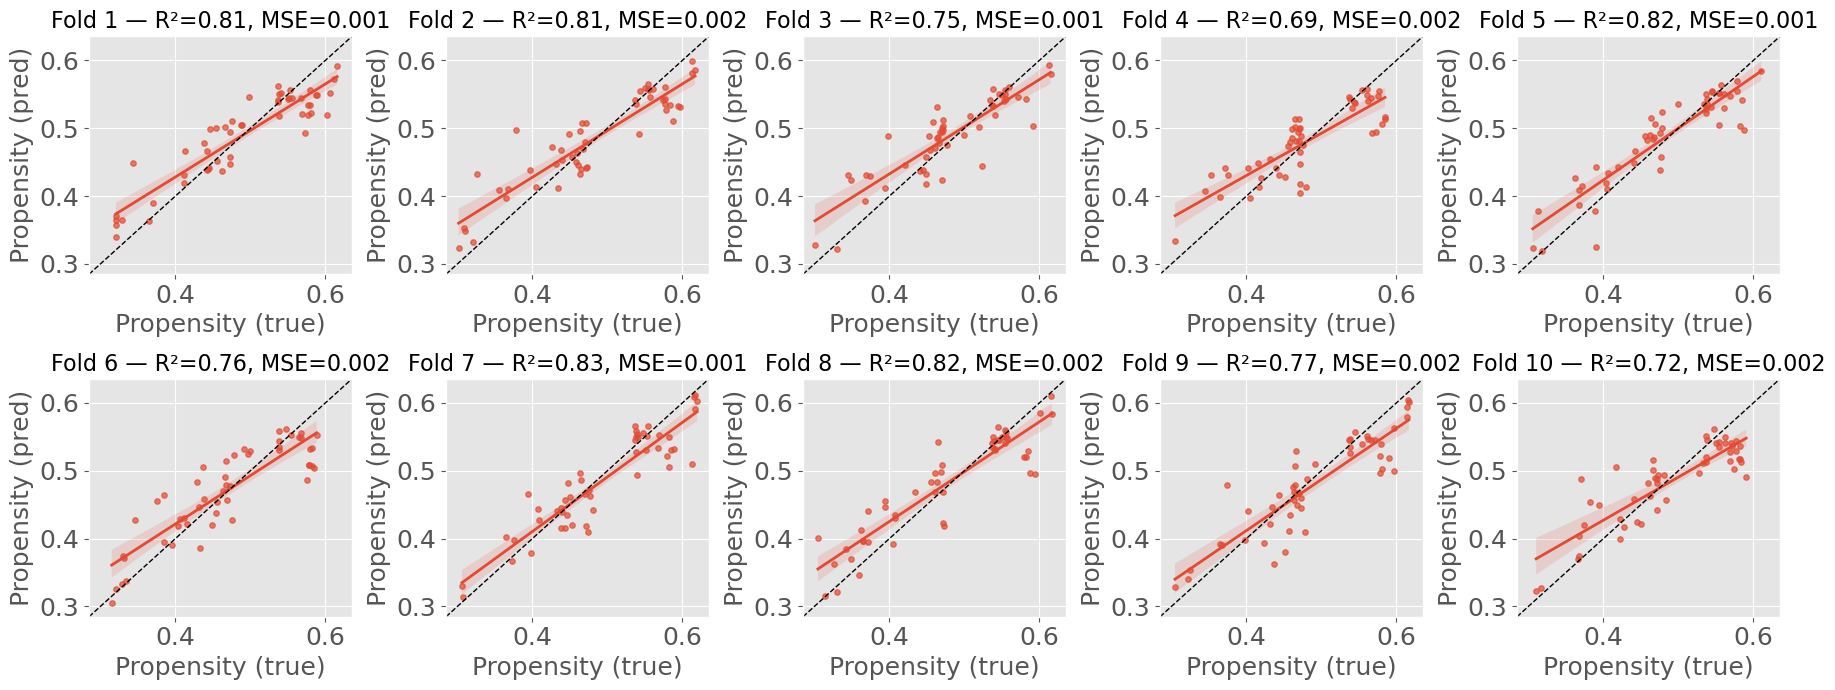

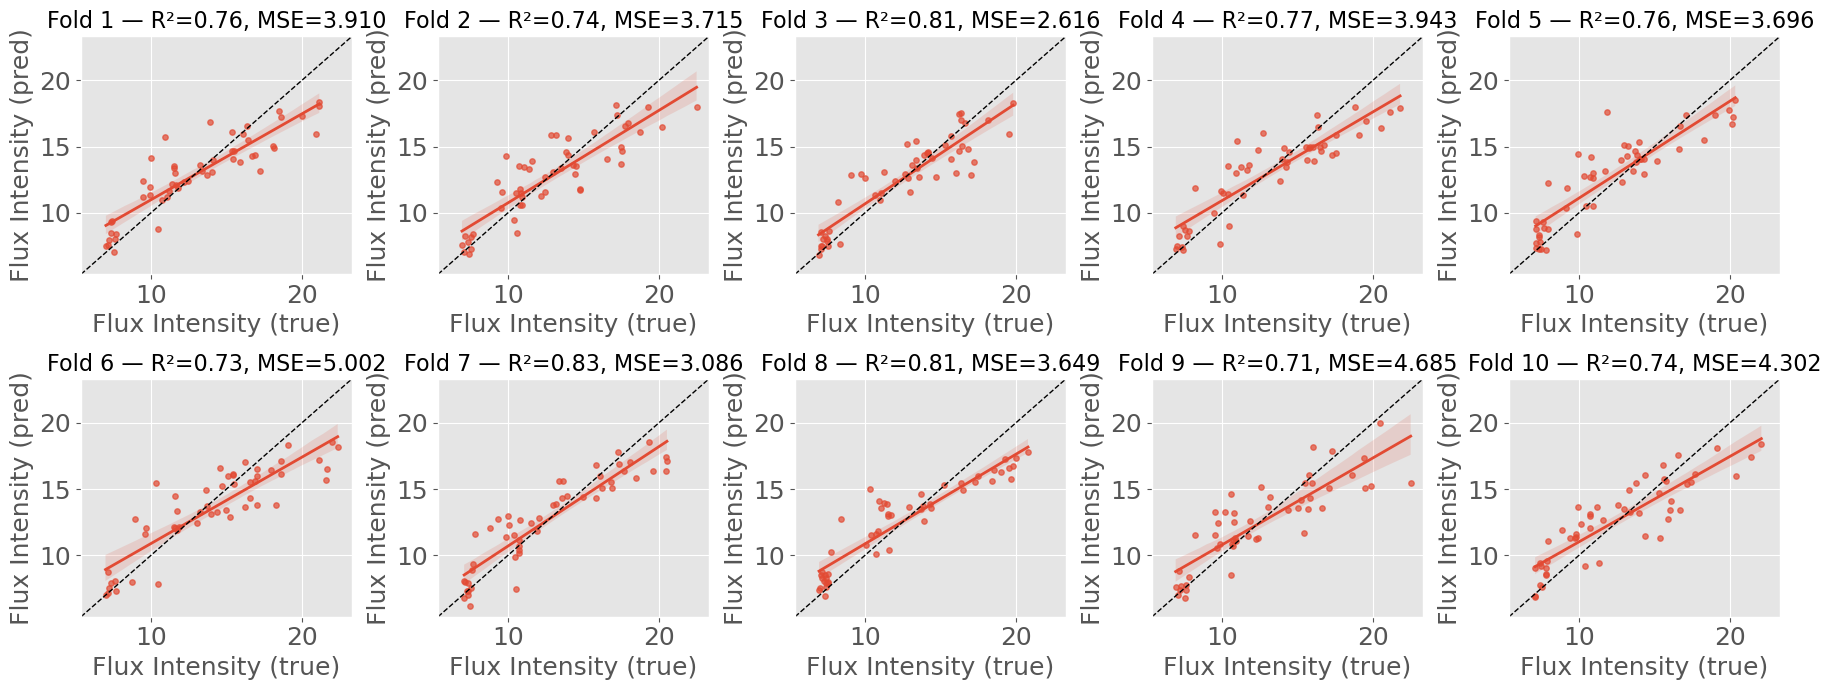

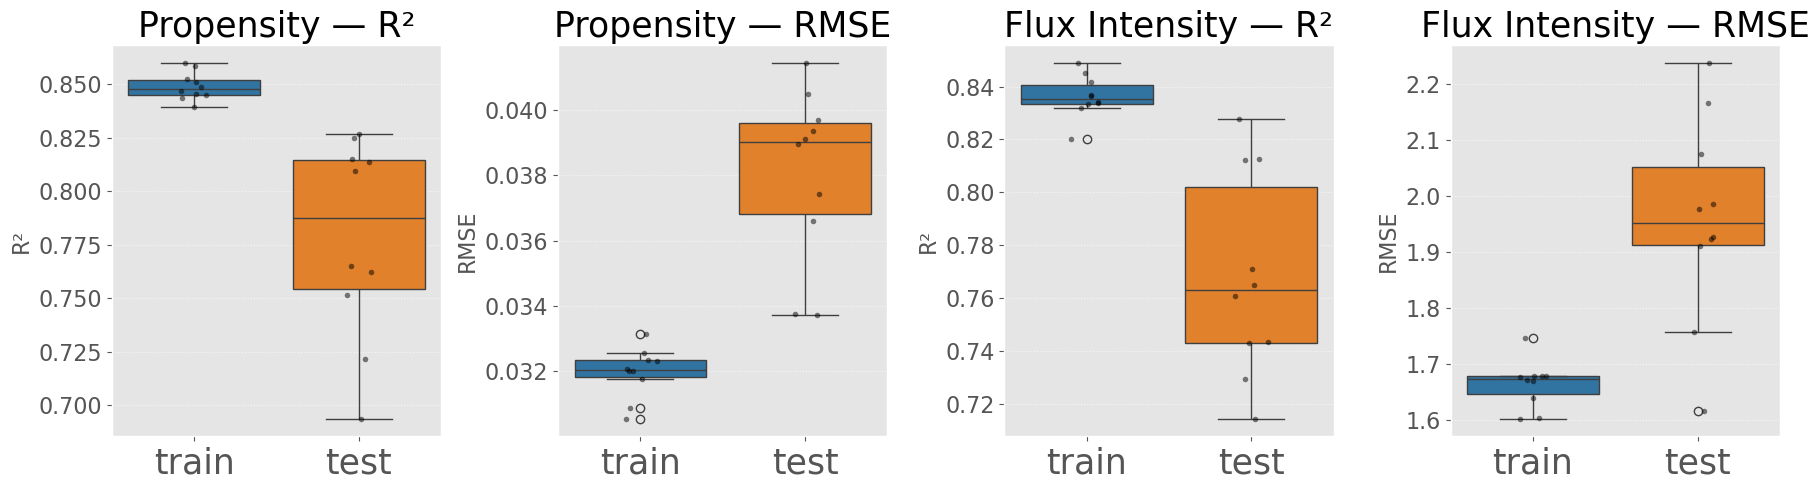

In [7]:
# Load predictions and make per-fold regplots with custom labels
preds_test = load_predictions_by_fold(METRICS_DIR, which="test")

figA = plot_reg_per_fold(preds_test, target="A", cols=5, figsize=(18, 7),
                         target_names=TARGET_LABELS)
figB = plot_reg_per_fold(preds_test, target="B", cols=5, figsize=(18, 7),
                         target_names=TARGET_LABELS)

figA.savefig(PLOTS_DIR / "regplot_per_fold_Propensity.png", dpi=600, bbox_inches="tight")
figB.savefig(PLOTS_DIR / "regplot_per_fold_FluxIntensity.png", dpi=600, bbox_inches="tight")

# Boxplot train vs test
fig = plot_box_train_test_metrics_per_target(METRICS_DIR,
                                             targets=('A','B'),
                                             target_names={'A':'Propensity','B':'Flux Intensity'},
                                             figsize=(18, 5))
fig.savefig(PLOTS_DIR / 'boxplots_by_target_r2_rmse.png', dpi=600, bbox_inches='tight')

plt.show()

### Ablation

In [3]:
import json, math
from typing import Sequence, Dict, Any, Optional

def r2_macro(y_true, y_pred):
    if y_true.ndim == 1:
        return r2_score(y_true, y_pred)
    r2s = [r2_score(y_true[:, j], y_pred[:, j]) for j in range(y_true.shape[1])]
    return float(np.mean(r2s))

def rmse_macro(y_true, y_pred):
    if y_true.ndim == 1:
        return float(np.sqrt(mean_squared_error(y_true, y_pred)))
    rmses = [np.sqrt(mean_squared_error(y_true[:, j], y_pred[:, j])) for j in range(y_true.shape[1])]
    return float(np.mean(rmses))

def load_best_params_for_folds(metadata_dir: Path) -> Dict[int, Dict[str, Any]]:

    params_by_fold: Dict[int, Dict[str, Any]] = {}
    for p in metadata_dir.glob("metadata_fold_*.json"):
        try:
            fold = int(p.stem.split("_")[-1])
        except Exception:
            continue
        with open(p, "r") as f:
            meta = json.load(f)
        best = meta.get("best_params", {})
        params_by_fold[fold] = best

    for p in metadata_dir.glob("fold_*"):
        if not p.is_dir(): 
            continue
        try:
            fold = int(str(p.name).split("_")[-1])
        except Exception:
            continue

        cand1 = p / f"metadata_fold_{fold:02d}.json"
        cand2 = p / "metadata.json"
        target = cand1 if cand1.exists() else (cand2 if cand2.exists() else None)
        if target is None:
            continue

        with open(target, "r") as f:
            meta = json.load(f)
        best = meta.get("best_params", {})
        params_by_fold[fold] = best  # sovrascrive eventuale root

    if not params_by_fold:
        raise RuntimeError(f"Nessun metadata trovato in {metadata_dir} (né root né fold_XX/*).")
    return params_by_fold

def _run_one_fold_task(
    k: int,
    tr_idx: np.ndarray,
    te_idx: np.ndarray,
    X_df: pd.DataFrame,
    y_mat: np.ndarray,
    modules: dict,
    best_params_k: Dict[str, Any],
    make_pipeline_fn,
    fractions,
    repeats,
    seed,
    outdir,
    make_plots,
    n_jobs_inner,
):
    return run_ablation_on_fold(
        X_df=X_df, y_mat=y_mat, modules=modules,
        tr_idx=tr_idx, te_idx=te_idx,
        best_params=best_params_k, make_pipeline_fn=make_pipeline_fn,
        fractions=fractions, repeats=repeats, seed=seed,
        fold_id=k, outdir=outdir, make_plots=make_plots,
        n_jobs_inner=n_jobs_inner
    )

def run_ablation_all_folds(
    X_df: pd.DataFrame,
    y_mat: np.ndarray,
    modules: dict,
    outer_cv,
    metadata_dir: Path,
    make_pipeline_fn,
    fractions: Sequence[float] = (0.25, 0.5, 0.75, 1.0),
    repeats: int = 3,
    seed: int = 42,
    outdir: Path = Path("./ablation_curves"),
    make_plots: bool = False,
    n_jobs_outer: Optional[int] = 1,   
    n_jobs_inner: Optional[int] = -1,  
) -> pd.DataFrame:

    params_by_fold = load_best_params_for_folds(metadata_dir)
    X = X_df.values
    fold_iter = list(outer_cv.split(X))
    K = len(fold_iter)

    if n_jobs_outer and n_jobs_outer != 1:
        n_jobs_inner = 1

        results = Parallel(n_jobs=n_jobs_outer, backend="loky", verbose=0)(
            delayed(_run_one_fold_task)(
                k+1, tr_idx, te_idx, X_df, y_mat, modules,
                params_by_fold.get(k+1, {}),
                make_pipeline_fn, fractions, repeats, seed,
                outdir, make_plots, n_jobs_inner
            )
            for k, (tr_idx, te_idx) in enumerate(fold_iter)
        )
        all_aggs_df = pd.concat(results, axis=0, ignore_index=True)
    else:
        all_aggs = []
        for k, (tr_idx, te_idx) in enumerate(fold_iter, start=1):
            if k not in params_by_fold:
                raise RuntimeError(f"Mancano i best_params per fold {k} in {metadata_dir}")
            agg = run_ablation_on_fold(
                X_df=X_df, y_mat=y_mat, modules=modules,
                tr_idx=tr_idx, te_idx=te_idx,
                best_params=params_by_fold[k], make_pipeline_fn=make_pipeline_fn,
                fractions=fractions, repeats=repeats, seed=seed,
                fold_id=k, outdir=outdir, make_plots=make_plots,
                n_jobs_inner=n_jobs_inner
            )
            all_aggs.append(agg)
        all_aggs_df = pd.concat(all_aggs, axis=0, ignore_index=True)

    all_aggs_df.to_csv(outdir / "ablation_all_folds_summary.csv", index=False)
    return all_aggs_df


In [4]:
def _ablation_task(
    fold_id: int,
    frac: float,
    r: int,
    tr_idx: np.ndarray,
    te_idx: np.ndarray,
    X: np.ndarray,
    y: np.ndarray,
    modules: dict,
    best_params: Dict[str, Any],
    make_pipeline_fn,
    seed: int,
    feature_names: Sequence[str],
):
    """
    Run one ablation job for a given fold, training-fraction, and repetition; return per-target and macro metrics.
    """
    frac_tag = int(round(frac * 1000))
    rng = np.random.default_rng(seed + 1000 * fold_id + 10 * frac_tag + r)

    X_tr, X_te = X[tr_idx], X[te_idx]
    y_tr, y_te = y[tr_idx], y[te_idx]

    n_sub = max(5, int(math.ceil(frac * len(tr_idx))))
    sub_idx_local = rng.choice(len(tr_idx), size=n_sub, replace=False)

    X_sub, y_sub = X_tr[sub_idx_local], y_tr[sub_idx_local]

    pipe = make_pipeline_fn(modules=modules, feature_names=feature_names, seed=seed)
    pipe.set_params(**best_params)

    pipe.fit(X_sub, y_sub)
    yhat_sub = pipe.predict(X_sub)
    yhat_te  = pipe.predict(X_te)

    if y_sub.ndim == 1:
        y_sub = y_sub.reshape(-1, 1)
    if y_te.ndim == 1:
        y_te = y_te.reshape(-1, 1)
    if isinstance(yhat_sub, np.ndarray) and yhat_sub.ndim == 1:
        yhat_sub = yhat_sub.reshape(-1, 1)
    if isinstance(yhat_te, np.ndarray) and yhat_te.ndim == 1:
        yhat_te = yhat_te.reshape(-1, 1)

    T = y_sub.shape[1]
    r2_train_list, rmse_train_list = [], []
    r2_test_list, rmse_test_list = [], []
    for j in range(T):
        r2_train_list.append(r2_score(y_sub[:, j], yhat_sub[:, j]))
        rmse_train_list.append(float(np.sqrt(mean_squared_error(y_sub[:, j], yhat_sub[:, j]))))
        r2_test_list.append(r2_score(y_te[:, j], yhat_te[:, j]))
        rmse_test_list.append(float(np.sqrt(mean_squared_error(y_te[:, j], yhat_te[:, j]))))

    out = {
        "fold": fold_id,
        "repeat": r + 1,
        "train_frac": float(frac),
        "n_train_used": int(n_sub),
        "R2_train": float(np.mean(r2_train_list)),
        "RMSE_train": float(np.mean(rmse_train_list)),
        "R2_test": float(np.mean(r2_test_list)),
        "RMSE_test": float(np.mean(rmse_test_list)),
        "R2_train_A": r2_train_list[0] if T >= 1 else np.nan,
        "RMSE_train_A": rmse_train_list[0] if T >= 1 else np.nan,
        "R2_test_A": r2_test_list[0] if T >= 1 else np.nan,
        "RMSE_test_A": rmse_test_list[0] if T >= 1 else np.nan,
        "R2_train_B": r2_train_list[1] if T >= 2 else np.nan,
        "RMSE_train_B": rmse_train_list[1] if T >= 2 else np.nan,
        "R2_test_B": r2_test_list[1] if T >= 2 else np.nan,
        "RMSE_test_B": rmse_test_list[1] if T >= 2 else np.nan,
    }
    return out


def run_ablation_on_fold(
    X_df: pd.DataFrame,
    y_mat: np.ndarray,
    modules: dict,
    tr_idx: np.ndarray,
    te_idx: np.ndarray,
    best_params: Dict[str, Any],
    make_pipeline_fn,
    fractions: Sequence[float] = (0.25, 0.5, 0.75, 1.0),
    repeats: int = 3,
    seed: int = 42,
    fold_id: int = 1,
    outdir: Path = Path("./ablation_curves"),
    make_plots: bool = False,
    n_jobs_inner: int = -1,        
) -> pd.DataFrame:
    """
    Run ablation on one fold across training fractions and repetitions; save raw and summarized CSVs and optional plots.
    """
    outdir.mkdir(parents=True, exist_ok=True)

    X = X_df.values.astype(np.float32)
    y = y_mat
    feature_names = list(X_df.columns)

    tasks = [(frac, r) for frac in fractions for r in range(repeats)]

    rows = Parallel(n_jobs=n_jobs_inner, backend="loky", verbose=0)(
        delayed(_ablation_task)(
            fold_id, frac, r, tr_idx, te_idx, X, y,
            modules, best_params, make_pipeline_fn,
            seed, feature_names
        )
        for (frac, r) in tasks
    )

    df = pd.DataFrame(rows)
    agg = (df.groupby(["fold", "train_frac"], as_index=False)
             .agg(
                 n_train_used=("n_train_used", "mean"),
                 R2_train_mean=("R2_train", "mean"),
                 R2_train_sd=("R2_train", "std"),
                 R2_test_mean=("R2_test", "mean"),
                 R2_test_sd=("R2_test", "std"),
                 RMSE_train_mean=("RMSE_train", "mean"),
                 RMSE_train_sd=("RMSE_train", "std"),
                 RMSE_test_mean=("RMSE_test", "mean"),
                 RMSE_test_sd=("RMSE_test", "std"),
                 R2_train_A=("R2_train_A", "mean"),
                 R2_test_A=("R2_test_A", "mean"),
                 RMSE_train_A=("RMSE_train_A", "mean"),
                 RMSE_test_A=("RMSE_test_A", "mean"),
                 R2_train_B=("R2_train_B", "mean"),
                 R2_test_B=("R2_test_B", "mean"),
                 RMSE_train_B=("RMSE_train_B", "mean"),
                 RMSE_test_B=("RMSE_test_B", "mean"),
             ))

    df.to_csv(outdir / f"ablation_fold_{fold_id:02d}_raw.csv", index=False)
    agg.to_csv(outdir / f"ablation_fold_{fold_id:02d}_summary.csv", index=False)

    if make_plots:
        x = agg["train_frac"].values
        plt.figure()
        plt.title(f"Ablation curve — Fold {fold_id}")
        plt.plot(x, agg["R2_train_mean"], marker="o", label="R2 Train")
        plt.plot(x, agg["R2_test_mean"],  marker="o", label="R2 Test")
        plt.xlabel("Training fraction"); plt.ylabel("R² (macro)")
        plt.legend(); plt.grid(True, alpha=0.3)
        plt.savefig(outdir / f"ablation_fold_{fold_id:02d}_R2.png", dpi=140, bbox_inches="tight")
        plt.close()

        plt.figure()
        plt.title(f"Ablation curve (RMSE) — Fold {fold_id}")
        plt.plot(x, agg["RMSE_train_mean"], marker="o", label="RMSE Train")
        plt.plot(x, agg["RMSE_test_mean"],  marker="o", label="RMSE Test")
        plt.xlabel("Training fraction"); plt.ylabel("RMSE (macro)")
        plt.legend(); plt.grid(True, alpha=0.3)
        plt.savefig(outdir / f"ablation_fold_{fold_id:02d}_RMSE.png", dpi=140, bbox_inches="tight")
        plt.close()

    return agg


def plot_ablation_summary_by_target(summary_csv: Path,
                                    outdir: Optional[Path] = None,
                                    target_names: Dict[str, str] = {'A': 'Propensity', 'B': 'Flux Intensity'}):
    """
    Plot per-target aggregated ablation curves (Train/Test) for targets A and B; expects per-target columns in the summary CSV.
    """
    df = pd.read_csv(summary_csv)
    if "train_frac" not in df.columns:
        raise ValueError(f"{summary_csv} is missing 'train_frac'.")

    g = (df.groupby("train_frac", as_index=False)
           .agg(
               R2_train_A_mean=("R2_train_A","mean"), R2_train_A_sd=("R2_train_A","std"),
               R2_test_A_mean =("R2_test_A","mean"),  R2_test_A_sd =("R2_test_A","std"),
               RMSE_train_A_mean=("RMSE_train_A","mean"), RMSE_train_A_sd=("RMSE_train_A","std"),
               RMSE_test_A_mean =("RMSE_test_A","mean"),  RMSE_test_A_sd =("RMSE_test_A","std"),
               R2_train_B_mean=("R2_train_B","mean"), R2_train_B_sd=("R2_train_B","std"),
               R2_test_B_mean =("R2_test_B","mean"),  R2_test_B_sd =("R2_test_B","std"),
               RMSE_train_B_mean=("RMSE_train_B","mean"), RMSE_train_B_sd=("RMSE_train_B","std"),
               RMSE_test_B_mean =("RMSE_test_B","mean"),  RMSE_test_B_sd =("RMSE_test_B","std"),
           )
           .sort_values("train_frac"))

    x = g["train_frac"].values
    outdir = Path(outdir) if outdir else Path(summary_csv).parent
    outdir.mkdir(parents=True, exist_ok=True)

    plt.figure(figsize=(7,5))
    plt.title(f"Ablation (R²) — {target_names.get('A','A')}")
    plt.plot(x, g["R2_train_A_mean"], "o-", label="Train R²")
    plt.fill_between(x, g["R2_train_A_mean"]-g["R2_train_A_sd"], g["R2_train_A_mean"]+g["R2_train_A_sd"], alpha=0.2)
    plt.plot(x, g["R2_test_A_mean"], "o-", label="Test R²")
    plt.fill_between(x, g["R2_test_A_mean"]-g["R2_test_A_sd"], g["R2_test_A_mean"]+g["R2_test_A_sd"], alpha=0.2)
    plt.xlabel("Training fraction"); plt.ylabel("R²"); plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout()
    plt.savefig(outdir / "ablation_R2_A.png", dpi=300, bbox_inches="tight")
    plt.close()

    plt.figure(figsize=(7,5))
    plt.title(f"Ablation (R²) — {target_names.get('B','B')}")
    plt.plot(x, g["R2_train_B_mean"], "o-", label="Train R²")
    plt.fill_between(x, g["R2_train_B_mean"]-g["R2_train_B_sd"], g["R2_train_B_mean"]+g["R2_train_B_sd"], alpha=0.2)
    plt.plot(x, g["R2_test_B_mean"], "o-", label="Test R²")
    plt.fill_between(x, g["R2_test_B_mean"]-g["R2_test_B_sd"], g["R2_test_B_mean"]+g["R2_test_B_sd"], alpha=0.2)
    plt.xlabel("Training fraction"); plt.ylabel("R²"); plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout()
    plt.savefig(outdir / "ablation_R2_B.png", dpi=300, bbox_inches="tight")
    plt.close()

    plt.figure(figsize=(7,5))
    plt.title(f"Ablation (RMSE) — {target_names.get('A','A')}")
    plt.plot(x, g["RMSE_train_A_mean"], "o-", label="Train RMSE")
    plt.fill_between(x, g["RMSE_train_A_mean"]-g["RMSE_train_A_sd"], g["RMSE_train_A_mean"]+g["RMSE_train_A_sd"], alpha=0.2)
    plt.plot(x, g["RMSE_test_A_mean"], "o-", label="Test RMSE")
    plt.fill_between(x, g["RMSE_test_A_mean"]-g["RMSE_test_A_sd"], g["RMSE_test_A_mean"]+g["RMSE_test_A_sd"], alpha=0.2)
    plt.xlabel("Training fraction"); plt.ylabel("RMSE"); plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout()
    plt.savefig(outdir / "ablation_RMSE_A.png", dpi=300, bbox_inches="tight")
    plt.close()

    plt.figure(figsize=(7,5))
    plt.title(f"Ablation (RMSE) — {target_names.get('B','B')}")
    plt.plot(x, g["RMSE_train_B_mean"], "o-", label="Train RMSE")
    plt.fill_between(x, g["RMSE_train_B_mean"]-g["RMSE_train_B_sd"], g["RMSE_train_B_mean"]+g["RMSE_train_B_sd"], alpha=0.2)
    plt.plot(x, g["RMSE_test_B_mean"], "o-", label="Test RMSE")
    plt.fill_between(x, g["RMSE_test_B_mean"]-g["RMSE_test_B_sd"], g["RMSE_test_B_mean"]+g["RMSE_test_B_sd"], alpha=0.2)
    plt.xlabel("Training fraction"); plt.ylabel("RMSE"); plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout()
    plt.savefig(outdir / "ablation_RMSE_B.png", dpi=300, bbox_inches="tight")
    plt.close()


In [12]:
ABL_OUT = Path("../data/ml_output/mt_en_results_test_4/ablation_out")
ABL_OUT.mkdir(parents=True, exist_ok=True)

In [ ]:
# Ablation across all folds (mean label A and B)
ablation_df = run_ablation_all_folds(
    X_df=X_use,
    y_mat=y,
    modules=modules,
    outer_cv=outer_cv,
    metadata_dir=Path("../data/ml_output/mt_en_results_test_4"),
    make_pipeline_fn=make_pipeline,
    fractions=(0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0),
    repeats=5,
    seed=SEED,
    outdir=ABL_OUT,
    make_plots=True,
    n_jobs_inner=-1,  
    n_jobs_outer=1   
)

print(ablation_df.head())


   fold  train_frac  n_train_used  R2_train_mean  R2_train_sd  R2_test_mean  \
0     1         0.3         139.0       0.939463     0.006641      0.710527   
1     1         0.4         185.0       0.931059     0.003779      0.734874   
2     1         0.5         231.0       0.929648     0.006103      0.808975   
3     1         0.6         277.0       0.924107     0.002442      0.799675   
4     1         0.7         323.0       0.918098     0.003122      0.807739   

   R2_test_sd  RMSE_train_mean  RMSE_train_sd  RMSE_test_mean  RMSE_test_sd  
0    0.033971         0.262396       0.006856        1.068318      0.109362  
1    0.020408         0.303791       0.008345        1.044510      0.077483  
2    0.022371         0.338079       0.005543        0.872417      0.026696  
3    0.026662         0.365383       0.006513        0.891519      0.090994  
4    0.004562         0.398529       0.002418        0.871420      0.020348  


In [18]:
def plot_ablation_summary(summary_csv: Path, outdir: Optional[Path] = None):

    df = pd.read_csv(summary_csv)
    if "train_frac" not in df.columns:
        raise ValueError(f"Il file {summary_csv} non contiene la colonna 'train_frac'.")

    grouped = (
        df.groupby("train_frac", as_index=False)
          .agg(
              R2_train_mean=("R2_train_mean", "mean"),
              R2_train_sd=("R2_train_mean", "std"),
              R2_test_mean=("R2_test_mean", "mean"),
              R2_test_sd=("R2_test_mean", "std"),
              RMSE_train_mean=("RMSE_train_mean", "mean"),
              RMSE_train_sd=("RMSE_train_mean", "std"),
              RMSE_test_mean=("RMSE_test_mean", "mean"),
              RMSE_test_sd=("RMSE_test_mean", "std"),
          )
          .sort_values("train_frac")
    )

    x = grouped["train_frac"].values
    outdir = Path(outdir) if outdir else summary_csv.parent
    outdir.mkdir(parents=True, exist_ok=True)

    plt.figure(figsize=(7, 5))
    plt.title("Aggregated ablation curve — all folds")

    plt.plot(x, grouped["R2_train_mean"], "o-", color="tab:red", label="R² Train")
    plt.fill_between(
        x,
        grouped["R2_train_mean"] - grouped["R2_train_sd"],
        grouped["R2_train_mean"] + grouped["R2_train_sd"],
        color="tab:red", alpha=0.2
    )

    plt.plot(x, grouped["R2_test_mean"], "o-", color="tab:blue", label="R² Test")
    plt.fill_between(
        x,
        grouped["R2_test_mean"] - grouped["R2_test_sd"],
        grouped["R2_test_mean"] + grouped["R2_test_sd"],
        color="tab:blue", alpha=0.2
    )

    plt.xlabel("Training fraction")
    plt.ylabel("R²")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    plt.savefig(outdir / "ablation_all_folds_R2.png", dpi=160, bbox_inches="tight")
    #plt.savefig(outdir / "ablation_all_folds_R2.pdf", dpi=160, bbox_inches="tight")
    plt.close()

    plt.figure(figsize=(7, 5))
    plt.title("Aggregated ablation curve — all folds")

    plt.plot(x, grouped["RMSE_train_mean"], "o-", color="tab:orange", label="RMSE Train")
    plt.fill_between(
        x,
        grouped["RMSE_train_mean"] - grouped["RMSE_train_sd"],
        grouped["RMSE_train_mean"] + grouped["RMSE_train_sd"],
        color="tab:orange", alpha=0.2
    )

    plt.plot(x, grouped["RMSE_test_mean"], "o-", color="tab:green", label="RMSE Test")
    plt.fill_between(
        x,
        grouped["RMSE_test_mean"] - grouped["RMSE_test_sd"],
        grouped["RMSE_test_mean"] + grouped["RMSE_test_sd"],
        color="tab:green", alpha=0.2
    )

    plt.xlabel("Training fraction")
    plt.ylabel("RMSE")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    plt.savefig(outdir / "ablation_all_folds_RMSE.png", dpi=160, bbox_inches="tight")
    # plt.savefig(outdir / "ablation_all_folds_RMSE.pdf", dpi=160, bbox_inches="tight")
    plt.close()

    print(f"plots saved in {outdir}")


In [19]:
plot_ablation_summary(
    summary_csv=ABL_OUT / "ablation_all_folds_summary.csv",
    outdir=ABL_OUT
)

plots saved in ..\data\ml_output\mt_en_results_test_4\ablation_out


---------------

In [ ]:
ABL_OUT = Path("../data/ml_output/mt_en_results_test_4/ablation_out")
ABL_OUT.mkdir(parents=True, exist_ok=True)

ablation_df = run_ablation_all_folds(
    X_df=X_use,
    y_mat=y,
    modules=modules,
    outer_cv=outer_cv,
    metadata_dir=Path("../data/ml_output/mt_en_results_test_4"),
    make_pipeline_fn=make_pipeline, 
    fractions=(0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0),
    repeats=5,
    seed=SEED,
    outdir=ABL_OUT,
    make_plots=False,
    n_jobs_inner=-1,
    n_jobs_outer=1
)

print(ablation_df.head())

plot_ablation_summary_by_target(
    summary_csv=ABL_OUT / "ablation_all_folds_summary.csv",
    outdir=ABL_OUT,
    target_names={'A': 'Propensity', 'B': 'Flux Intensity'}
)

   fold  train_frac  n_train_used  R2_train_mean  R2_train_sd  R2_test_mean  \
0     1         0.3         139.0       0.939463     0.006641      0.710527   
1     1         0.4         185.0       0.931059     0.003779      0.734874   
2     1         0.5         231.0       0.929648     0.006103      0.808975   
3     1         0.6         277.0       0.924107     0.002442      0.799675   
4     1         0.7         323.0       0.918098     0.003122      0.807739   

   R2_test_sd  RMSE_train_mean  RMSE_train_sd  RMSE_test_mean  RMSE_test_sd  \
0    0.033971         0.262396       0.006856        1.068318      0.109362   
1    0.020408         0.303791       0.008345        1.044510      0.077483   
2    0.022371         0.338079       0.005543        0.872417      0.026696   
3    0.026662         0.365383       0.006513        0.891519      0.090994   
4    0.004562         0.398529       0.002418        0.871420      0.020348   

   R2_train_A  R2_test_A  RMSE_train_A  RMSE_test_

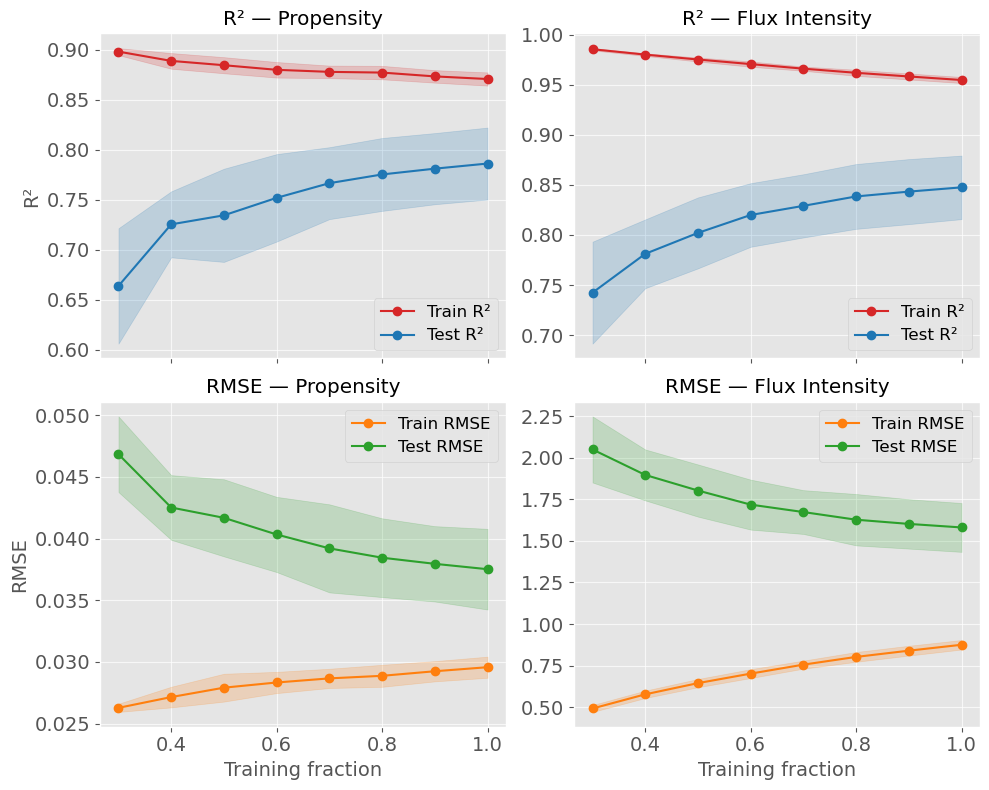

In [15]:
csv_path = Path("../data/ml_output/mt_en_results_test_4/ablation_out_label_sep/ablation_all_folds_summary.csv")
df = pd.read_csv(csv_path)

g = (
    df.groupby("train_frac", as_index=False)
      .agg(
          R2_train_A_mean=("R2_train_A", "mean"), R2_train_A_sd=("R2_train_A", "std"),
          R2_test_A_mean=("R2_test_A", "mean"), R2_test_A_sd=("R2_test_A", "std"),
          RMSE_train_A_mean=("RMSE_train_A", "mean"), RMSE_train_A_sd=("RMSE_train_A", "std"),
          RMSE_test_A_mean=("RMSE_test_A", "mean"), RMSE_test_A_sd=("RMSE_test_A", "std"),
          R2_train_B_mean=("R2_train_B", "mean"), R2_train_B_sd=("R2_train_B", "std"),
          R2_test_B_mean=("R2_test_B", "mean"), R2_test_B_sd=("R2_test_B", "std"),
          RMSE_train_B_mean=("RMSE_train_B", "mean"), RMSE_train_B_sd=("RMSE_train_B", "std"),
          RMSE_test_B_mean=("RMSE_test_B", "mean"), RMSE_test_B_sd=("RMSE_test_B", "std"),
      )
      .sort_values("train_frac")
)

x = g["train_frac"].values

fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True)
(ax1, ax2), (ax3, ax4) = axes

# --- (A) R² Propensity ---
ax1.plot(x, g["R2_train_A_mean"], "o-", color="tab:red", label="Train R²")
ax1.fill_between(x, g["R2_train_A_mean"]-g["R2_train_A_sd"], g["R2_train_A_mean"]+g["R2_train_A_sd"], color="tab:red", alpha=0.2)
ax1.plot(x, g["R2_test_A_mean"], "o-", color="tab:blue", label="Test R²")
ax1.fill_between(x, g["R2_test_A_mean"]-g["R2_test_A_sd"], g["R2_test_A_mean"]+g["R2_test_A_sd"], color="tab:blue", alpha=0.2)
ax1.set_title("R² — Propensity")
ax1.set_ylabel("R²", fontsize=14)
ax1.grid(True, alpha=0.7)
ax1.tick_params(axis="both", labelsize=14)
ax1.legend(fontsize=12)

# --- (B) R² Flux Intensity ---
ax2.plot(x, g["R2_train_B_mean"], "o-", color="tab:red", label="Train R²")
ax2.fill_between(x, g["R2_train_B_mean"]-g["R2_train_B_sd"], g["R2_train_B_mean"]+g["R2_train_B_sd"], color="tab:red", alpha=0.2)
ax2.plot(x, g["R2_test_B_mean"], "o-", color="tab:blue", label="Test R²")
ax2.fill_between(x, g["R2_test_B_mean"]-g["R2_test_B_sd"], g["R2_test_B_mean"]+g["R2_test_B_sd"], color="tab:blue", alpha=0.2)
ax2.set_title("R² — Flux Intensity")
ax2.tick_params(axis="both", labelsize=14)
ax2.grid(True, alpha=0.7)
ax2.legend(fontsize=12)

# --- (C) RMSE Propensity ---
ax3.plot(x, g["RMSE_train_A_mean"], "o-", color="tab:orange", label="Train RMSE")
ax3.fill_between(x, g["RMSE_train_A_mean"]-g["RMSE_train_A_sd"], g["RMSE_train_A_mean"]+g["RMSE_train_A_sd"], color="tab:orange", alpha=0.2)
ax3.plot(x, g["RMSE_test_A_mean"], "o-", color="tab:green", label="Test RMSE")
ax3.fill_between(x, g["RMSE_test_A_mean"]-g["RMSE_test_A_sd"], g["RMSE_test_A_mean"]+g["RMSE_test_A_sd"], color="tab:green", alpha=0.2)
ax3.set_title("RMSE — Propensity")
ax3.set_xlabel("Training fraction", fontsize=14)
ax3.tick_params(axis="both", labelsize=14)
ax3.set_ylabel("RMSE", fontsize=14)
ax3.grid(True, alpha=0.7)
ax3.legend(fontsize=12)

# --- (D) RMSE Flux Intensity ---
ax4.plot(x, g["RMSE_train_B_mean"], "o-", color="tab:orange", label="Train RMSE")
ax4.fill_between(x, g["RMSE_train_B_mean"]-g["RMSE_train_B_sd"], g["RMSE_train_B_mean"]+g["RMSE_train_B_sd"], color="tab:orange", alpha=0.2)
ax4.plot(x, g["RMSE_test_B_mean"], "o-", color="tab:green", label="Test RMSE")
ax4.fill_between(x, g["RMSE_test_B_mean"]-g["RMSE_test_B_sd"], g["RMSE_test_B_mean"]+g["RMSE_test_B_sd"], color="tab:green", alpha=0.2)
ax4.set_title("RMSE — Flux Intensity")
ax4.set_xlabel("Training fraction", fontsize=14)
ax4.tick_params(axis="both", labelsize=14)
ax4.grid(True, alpha=0.7)
ax4.legend(fontsize=12)

plt.tight_layout()
plt.savefig(csv_path.parent / "ablation_all_folds_per_target.png", dpi=600, bbox_inches="tight")
plt.show()



### Features Selection 

#### Coef > 0

In [11]:
def _discover_fold_coefs_files(outdir: Path):
    """
    Find per-fold coefficient CSVs.
    Priority:
      1) fold_{kk}/coefs_fold_{kk}.csv
      2) fold_{kk}/coefs.csv
      3) flat: coefs_fold_{k}.csv
    Returns: dict {fold_id (int): Path}
    """
    outdir = Path(outdir)
    found = {}

    # inside fold directories
    for fd in sorted(outdir.glob("fold_*")):
        if not fd.is_dir():
            continue
        kk = fd.name.split("_")[-1]
        cand1 = fd / f"coefs_fold_{kk}.csv"
        cand2 = fd / "coefs.csv"
        if cand1.exists():
            found[int(kk)] = cand1
        elif cand2.exists():
            found[int(kk)] = cand2

    # flat fallback
    if not found:
        for fp in outdir.glob("coefs_fold_*.csv"):
            m = re.match(r"coefs_fold_(\d+)\.csv$", fp.name)
            if m:
                k = int(m.group(1))
                found[k] = fp

    return dict(sorted(found.items()))

def _ensure_coef_norm(df: pd.DataFrame) -> pd.DataFrame:
    """
    Ensure df has a 'coef_norm' column. If missing and columns
    ['coef_A','coef_B'] exist, compute L2 norm.
    """
    if "coef_norm" not in df.columns:
        if {"coef_A", "coef_B"}.issubset(df.columns):
            df = df.copy()
            df["coef_norm"] = np.sqrt(df["coef_A"]**2 + df["coef_B"]**2)
        else:
            raise ValueError("Coefficient file lacks 'coef_norm' and ('coef_A','coef_B').")
    return df

def compute_gene_and_module_stability(outdir,
                                      modules: dict,
                                      min_abs_coef: float = 0.0,
                                      save_outputs: bool = True,
                                      genes_colname: str = "genes",
                                      sep: str = ";"):
    """
    Compute stability at both GENE- and MODULE-level from per-fold coef CSVs.

    It works whether your coef files are gene-level or module-level:
    - If coef index are genes: a gene is "selected" when |coef_norm| > threshold.
      A module is "selected" in a fold if ANY of its genes is selected.
    - If coef index are modules: a module is "selected" when |coef_norm| > threshold.
      All genes in a selected module are marked selected for the gene matrix.

    Args
    ----
    outdir : str | Path
        Folder with coefs files (possibly inside fold_{kk}/ subfolders).
    modules : dict
        Mapping {module_name: [gene1, gene2, ...]} used during training.
    min_abs_coef : float
        Threshold on |coef_norm| to consider a feature selected (default 0).
    save_outputs : bool
        If True, writes four files in `outdir`:
          - gene_selection_matrix.csv
          - gene_stability_scores.csv
          - module_selection_matrix.csv
          - module_stability_scores.csv (with a column listing genes)
    genes_colname : str
        Column name used in module stability output to list member genes.
    sep : str
        Separator used to join gene names in the module stability table.

    Returns
    -------
    gene_sel : DataFrame (genes × folds) with 0/1
    gene_stab: DataFrame with ['gene','n_selected','n_folds','stability']
    mod_sel  : DataFrame (modules × folds) with 0/1
    mod_stab : DataFrame with ['module','n_genes','n_selected','n_folds','stability', genes_colname]
    """
    outdir = Path(outdir)
    coefs_files = _discover_fold_coefs_files(outdir)
    if not coefs_files:
        raise FileNotFoundError(f"No coefs files found in {outdir}")

    folds = sorted(coefs_files.keys())

    # Module <-> gene maps
    mod2genes = {m: list(set(gs)) for m, gs in modules.items()}
    all_modules = sorted(mod2genes.keys())
    gene_set_from_modules = set(g for gs in mod2genes.values() for g in gs)

    # Detect whether incoming coef index looks like genes or modules
    # (use first file as probe)
    probe = pd.read_csv(coefs_files[folds[0]], index_col=0)
    idx = set(probe.index)
    n_idx_in_gene_set = len(idx & gene_set_from_modules)
    n_idx_in_module_set = len(idx & set(all_modules))
    looks_like_genes = n_idx_in_gene_set >= n_idx_in_module_set

    # Universe of features at each level
    if looks_like_genes:
        # union of all genes appearing across all folds
        all_genes = set()
        for k in folds:
            df = pd.read_csv(coefs_files[k], index_col=0)
            all_genes |= set(df.index.tolist())
        all_genes = sorted(all_genes)

        # all modules taken from modules dict
        all_mods = all_modules
    else:
        # union of all modules appearing across all folds
        all_mods = set()
        for k in folds:
            df = pd.read_csv(coefs_files[k], index_col=0)
            all_mods |= set(df.index.tolist())
        all_mods = sorted(all_mods)

        # derive genes from listed modules
        all_genes = sorted(set(g for m in all_mods for g in mod2genes.get(m, [])))

    # Prepare empty selection matrices
    gene_sel = pd.DataFrame(0, index=all_genes, columns=[f"fold_{k}" for k in folds], dtype=int)
    mod_sel  = pd.DataFrame(0, index=all_mods,  columns=[f"fold_{k}" for k in folds], dtype=int)

    # Fill matrices
    for k in folds:
        df = pd.read_csv(coefs_files[k], index_col=0)
        df = _ensure_coef_norm(df)

        col = f"fold_{k}"

        if looks_like_genes:
            # GENE-LEVEL FILES
            # mark selected genes
            selected_genes = set(df.index[df["coef_norm"].values > float(min_abs_coef)])
            gene_sel.loc[gene_sel.index.intersection(selected_genes), col] = 1

            # MODULE selected = any selected gene within that module
            for m, genes in mod2genes.items():
                if len(set(genes) & selected_genes) > 0:
                    if m in mod_sel.index:
                        mod_sel.loc[m, col] = 1
        else:
            # MODULE-LEVEL FILES
            selected_mods = set(df.index[df["coef_norm"].values > float(min_abs_coef)])
            mod_sel.loc[mod_sel.index.intersection(selected_mods), col] = 1

            # propagate selection to member genes
            selected_genes = set(g for m in selected_mods for g in mod2genes.get(m, []))
            gene_sel.loc[gene_sel.index.intersection(selected_genes), col] = 1

    # Stability summaries
    n_f = len(folds)

    gene_nsel = gene_sel.sum(axis=1)
    gene_stab = (
        pd.DataFrame({
            "gene": gene_sel.index,
            "n_selected": gene_nsel.values,
            "n_folds": n_f,
            "stability": (gene_nsel / n_f).values
        })
        .query("n_selected > 0")
        .sort_values(["stability", "n_selected", "gene"], ascending=[False, False, True])
        .reset_index(drop=True)
    )

    mod_nsel = mod_sel.sum(axis=1)
    # also attach the list of genes per module
    mod_genes_col = [
        sep.join(sorted(mod2genes.get(m, []))) for m in mod_sel.index
    ]
    mod_stab = (
        pd.DataFrame({
            "module": mod_sel.index,
            "n_genes": [len(mod2genes.get(m, [])) for m in mod_sel.index],
            "n_selected": mod_nsel.values,
            "n_folds": n_f,
            "stability": (mod_nsel / n_f).values,
            genes_colname: mod_genes_col
        })
        .query("n_selected > 0")
        .sort_values(["stability", "n_selected", "module"], ascending=[False, False, True])
        .reset_index(drop=True)
    )

    # Save files
    if save_outputs:
        gene_sel.to_csv(outdir / "gene_selection_matrix.csv", index=True)
        gene_stab.to_csv(outdir / "gene_stability_scores.csv", index=False)
        mod_sel.to_csv(outdir / "module_selection_matrix.csv", index=True)
        mod_stab.to_csv(outdir / "module_stability_scores.csv", index=False)

    return gene_sel, gene_stab, mod_sel, mod_stab


In [ ]:
OUTDIR_SCORE = Path("../data/ml_output/mt_en_results_test_4")
gene_sel, gene_stab, mod_sel, mod_stab = compute_gene_and_module_stability(
    outdir=OUTDIR_SCORE,
    modules=modules,
    min_abs_coef=1e-6,  # threshold on |coef_norm|
    save_outputs=False,
    genes_colname="genes",
    sep="\n"
)

In [ ]:
# gene_sel.to_csv(OUTDIR_SCORE / "gene_selection_matrix.csv", index=True)
# gene_stab.to_csv(OUTDIR_SCORE / "gene_stability_scores.csv", index=True)
# mod_sel.to_csv(OUTDIR_SCORE / "module_selection_matrix.csv", index=True)
# mod_stab.to_csv(OUTDIR_SCORE / "module_stability_scores.csv", index=True)

<Axes: xlabel='stability', ylabel='Count'>

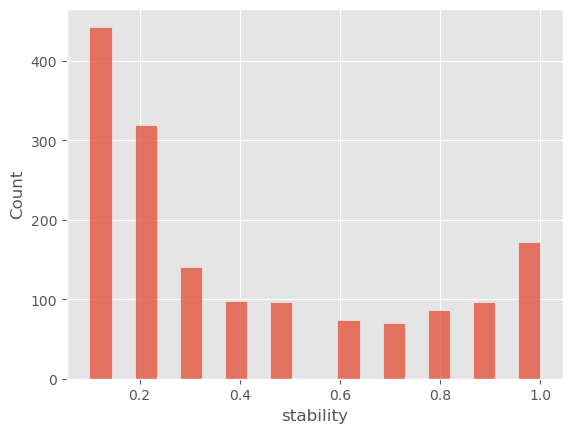

In [44]:
sns.histplot(gene_stab["stability"], bins=20, kde=False)

In [45]:
def print_stable_gene_ids(gene_stab, thr=0.8, id_col="gene", score_col="stability"):
    """
    Print and return the gene IDs whose stability >= thr.

    Parameters
    ----------
    gene_stab : pandas.DataFrame
        Table with at least the gene ID column and a stability score column.
    thr : float
        Threshold on stability (inclusive).
    id_col : str
        Name of the column containing gene IDs (e.g. "gene", "gene_id", "ensembl_id").
    score_col : str
        Name of the stability score column (e.g. "stability", "pct_selected").

    Returns
    -------
    list
        List of gene IDs passing the threshold.
    """
    # If IDs are in the index, bring them to a column named id_col
    df = gene_stab.reset_index() if id_col not in gene_stab.columns else gene_stab.copy()

    # Filter and sort (optional)
    hits = df.loc[df[score_col] >= thr, [id_col, score_col]].sort_values(score_col, ascending=False)

    # Print only the IDs (one per line)
    for gid in hits[id_col]:
        print(gid)

    return hits[id_col].tolist()


In [49]:
stable_ids = print_stable_gene_ids(gene_stab, thr=0.9, id_col="gene", score_col="stability")

ENSG00000006459
ENSG00000196092
ENSG00000182871
ENSG00000183657
ENSG00000184500
ENSG00000187862
ENSG00000188910
ENSG00000188959
ENSG00000189280
ENSG00000189433
ENSG00000196329
ENSG00000182782
ENSG00000196411
ENSG00000196639
ENSG00000196754
ENSG00000196878
ENSG00000196923
ENSG00000198561
ENSG00000198821
ENSG00000198851
ENSG00000182795
ENSG00000181885
ENSG00000167767
ENSG00000175029
ENSG00000168143
ENSG00000168497
ENSG00000169575
ENSG00000171219
ENSG00000171401
ENSG00000172995
ENSG00000173467
ENSG00000173762
ENSG00000175315
ENSG00000179604
ENSG00000175707
ENSG00000177202
ENSG00000177337
ENSG00000177426
ENSG00000177685
ENSG00000178038
ENSG00000178386
ENSG00000179178
ENSG00000203499
ENSG00000203697
ENSG00000205890
ENSG00000262001
ENSG00000260231
ENSG00000260302
ENSG00000260655
ENSG00000260941
ENSG00000261116
ENSG00000261183
ENSG00000261602
ENSG00000261664
ENSG00000263432
ENSG00000206075
ENSG00000266010
ENSG00000266927
ENSG00000267530
ENSG00000267654
ENSG00000268927
ENSG00000271303
ENSG0000

#### Elbow

In [12]:
OUTDIR_SCORE = Path("../data/ml_output/mt_en_results_test_4")
OUTDIR = Path(OUTDIR_SCORE) 
PLOTS_DIR = OUTDIR / "performance_plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

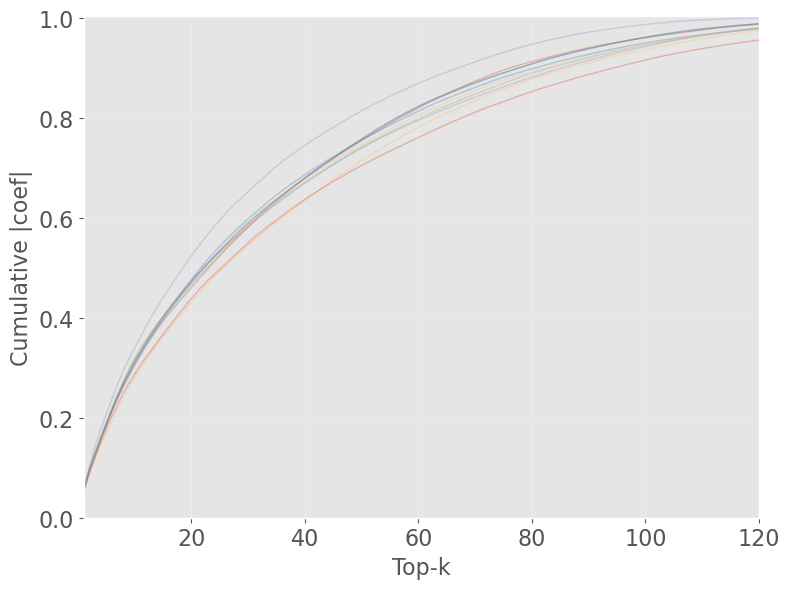

Saved cumulative plot: ..\data\ml_output\mt_en_results_test_4\performance_plots\cumulative_abscoef_folds_en.png

Top-k to reach the threshold (median [min–max]) and % of features:
  60%  -> k_med=32  [26–36],   %med=21.5%  [19.7–22.9]
  65%  -> k_med=37  [30–42],   %med=25.1%  [22.9–26.8]
  70%  -> k_med=43  [35–50],   %med=29.5%  [26.8–30.6]
  75%  -> k_med=50  [41–58],   %med=34.2%  [31.8–35.7]
  80%  -> k_med=58  [48–68],   %med=39.9%  [36.9–40.8]
  85%  -> k_med=68  [57–80],   %med=46.7%  [43.3–47.5]
Saved thresholds summary: ..\data\ml_output\mt_en_results_test_4\en_cumulative_thresholds_summary.csv


In [13]:
coefs_files = _discover_fold_coefs_files(OUTDIR)
assert coefs_files, f"No coef files found in {OUTDIR}"

curves = []
fold_labels = []
for fold_id, fp in sorted(coefs_files.items()):
    df = pd.read_csv(fp, index_col=0)
    df = _ensure_coef_norm(df)

    # Use absolute coefficients; replace NaN with 0 and clip negatives (safety)
    w = np.asarray(df["coef_norm"], dtype=float)
    w = np.nan_to_num(np.abs(w), nan=0.0)
    w = np.maximum(w, 0.0)

    # Discard zeros before normalization (keeps only informative features)
    mask_nz = w > 0
    if not np.any(mask_nz):
        print(f"[Warn] Fold {fold_id}: all-zero |coef| — skipping.")
        continue
    w = w[mask_nz]

    # Normalize to sum=1, sort descending, cumulative sum
    s = w.sum()
    if s > 0:
        w = w / s
    w_sorted = np.sort(w)[::-1]
    csum = np.cumsum(w_sorted)

    curves.append(csum)
    fold_labels.append((fold_id, len(w)))

nmin = min(len(c) for c in curves)
x = np.arange(1, nmin + 1)

fig, ax = plt.subplots(figsize=(8, 6))
for (fold_id, nfeat), c in zip(fold_labels, curves):
    ax.plot(x, c[:nmin], lw=1, alpha=0.35)

ax.set_ylim(0, 1.005)
ax.set_xlim(1, nmin)
ax.set_xlabel("Top-k", fontsize=16)
ax.set_ylabel("Cumulative |coef|", fontsize=16)
ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=16)
ax.grid(True, alpha=0.2)
fig.tight_layout()

out_plot = PLOTS_DIR / "cumulative_abscoef_folds_en.png"
fig.savefig(out_plot, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved cumulative plot: {out_plot}")

thresholds = [0.60, 0.65, 0.70, 0.75, 0.80, 0.85]

k_at_thr = {t: [int(np.searchsorted(c, t) + 1) for c in curves] for t in thresholds}
n_feats_per_fold = [len(c) for c in curves]

print("\nTop-k to reach the threshold (median [min–max]) and % of features:")
rows_summary = []
for t in thresholds:
    ks = np.array(k_at_thr[t])
    ps = np.array(n_feats_per_fold)
    perc = 100 * ks / ps
    print(f"  {int(t*100)}%  -> k_med={int(np.median(ks))}  "
          f"[{ks.min()}–{ks.max()}],   "
          f"%med={np.median(perc):.1f}%  [{perc.min():.1f}–{perc.max():.1f}]")
    rows_summary.append({
        "threshold": t,
        "k_med": int(np.median(ks)),
        "k_min": int(ks.min()),
        "k_max": int(ks.max()),
        "pct_med": float(np.median(perc)),
        "pct_min": float(perc.min()),
        "pct_max": float(perc.max()),
    })

summary_df = pd.DataFrame(rows_summary)
summary_csv = OUTDIR / "en_cumulative_thresholds_summary.csv"
summary_df.to_csv(summary_csv, index=False)
print(f"Saved thresholds summary: {summary_csv}")


Kneedle per fold (knee_k & threshold):
 fold importance_type  n_features_after_zero_filter  knee_k  knee_threshold
    1         abscoef                           144      55        0.788780
    2         abscoef                           157      53        0.774475
    3         abscoef                           153      51        0.745968
    4         abscoef                           143      54        0.786509
    5         abscoef                           157      60        0.781139
    6         abscoef                           153      54        0.765955
    7         abscoef                           147      51        0.753087
    8         abscoef                           169      58        0.750334
    9         abscoef                           146      54        0.785437
   10         abscoef                           120      41        0.753043

Saved summary: ..\data\ml_output\mt_en_results_test_4\en_kneedle_folds_summary.csv


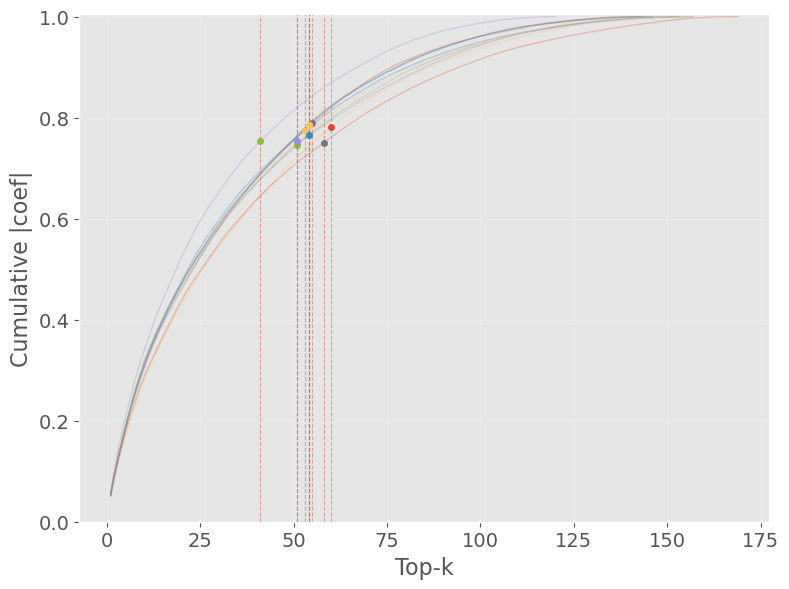

Saved knee overlay plot: ..\data\ml_output\mt_en_results_test_4\performance_plots\cumulative_abscoef_knee_overlay_en.png


In [45]:
from kneed import KneeLocator

KNEED_PARAMS = dict(
    curve="concave", 
    direction="increasing",
    S=5.0, # higher -> more conservative knee
    online=True,
    interp_method="polynomial",
    polynomial_degree=7,
)

knee_rows = []
knee_xs, knee_ys = [], []

# fold_labels for EN were built as [(fold_id, nfeat)], so adapt unpacking
for (fold_id, nfeat), csum in zip(fold_labels, curves):
    x_full = np.arange(1, len(csum) + 1, dtype=float)
    y_full = csum.astype(float)

    # Normalized versions for the fallback
    x_norm = (x_full - x_full.min()) / (x_full.max() - x_full.min())
    y_norm = y_full / y_full.max() if y_full.max() > 0 else y_full

    # Try Kneedle
    try:
        kl = KneeLocator(x_full, y_full, **KNEED_PARAMS)
        if kl.knee is not None:
            knee_x = float(kl.knee)
            knee_y = float(kl.knee_y)
        else:
            # Fallback: maximum vertical distance from the diagonal
            diff = y_norm - x_norm
            ki = int(np.argmax(diff))
            knee_x = float(x_full[ki])
            knee_y = float(y_full[ki])
    except Exception:
        diff = y_norm - x_norm
        ki = int(np.argmax(diff))
        knee_x = float(x_full[ki])
        knee_y = float(y_full[ki])

    # Convert to discrete top-k and clamp
    k_opt = int(round(knee_x))
    k_opt = max(1, min(k_opt, len(csum)))
    thr_opt = float(y_full[k_opt - 1] / y_full[-1])  # normalized cum-threshold at knee

    knee_rows.append({
        "fold": fold_id,
        "importance_type": "abscoef",
        "n_features_after_zero_filter": nfeat,
        "knee_k": k_opt,
        "knee_threshold": thr_opt,
        "knee_x_raw": knee_x,
        "knee_y_raw": knee_y,
    })
    knee_xs.append(k_opt)
    knee_ys.append(y_full[k_opt - 1])

# Save summary CSV
knee_df = pd.DataFrame(knee_rows).sort_values("fold")
knee_csv = OUTDIR / "en_kneedle_folds_summary.csv"   # OUTDIR = Path(OUTDIR_SCORE) in your EN block
knee_df.to_csv(knee_csv, index=False)

print("\nKneedle per fold (knee_k & threshold):")
print(knee_df[["fold", "importance_type", "n_features_after_zero_filter", "knee_k", "knee_threshold"]].to_string(index=False))
print(f"\nSaved summary: {knee_csv}")

# Overlay plot with knee markers
fig_knee, ax_knee = plt.subplots(figsize=(8, 6))

# Re-plot all curves with their own x scale
for (fold_id, nfeat), csum in zip(fold_labels, curves):
    x_full = np.arange(1, len(csum) + 1, dtype=float)
    ax_knee.plot(x_full, csum, lw=1, alpha=0.30)

# Knee verticals + points
for (fold_id, _), kx, ky in zip(fold_labels, knee_xs, knee_ys):
    ax_knee.axvline(kx, ls="--", lw=0.8, alpha=0.45)
    ax_knee.plot([kx], [ky], "o", ms=4)

ax_knee.set_xlabel("Top-k", fontsize=16)
ax_knee.set_ylabel("Cumulative |coef|", fontsize=16)
ax_knee.tick_params(axis='x', labelsize=14)
ax_knee.tick_params(axis='y', labelsize=14)
ax_knee.set_ylim(0, 1.005)
ax_knee.grid(True, alpha=0.2)
fig_knee.tight_layout()

out_knee_plot = PLOTS_DIR / "cumulative_abscoef_knee_overlay_en.png"
fig_knee.savefig(out_knee_plot, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved knee overlay plot: {out_knee_plot}")


In [ ]:
def _load_en_knees_if_available(outdir: Path):
    """
    Try to load precomputed knees from en_kneedle_folds_summary.csv.
    Returns dict fold -> knee_k, or {} if file not found/invalid.
    """
    knee_csv = Path(outdir) / "en_kneedle_folds_summary.csv"
    if not knee_csv.exists():
        return {}
    knee_df = pd.read_csv(knee_csv)
    if not {"fold", "knee_k"}.issubset(knee_df.columns):
        return {}
    return {int(r["fold"]): int(r["knee_k"]) for _, r in knee_df.iterrows()}

def compute_gene_and_module_stability_en(
    outdir,
    modules: dict,
    kneed_params: dict = None,
    use_precomputed_knees: bool = True,
    save_outputs: bool = True,
    genes_colname: str = "genes",
    sep: str = ";"
):
    """
    Compute stability at both GENE- and MODULE-level from per-fold ElasticNet coef CSVs,
    selecting features up to the knee (Kneedle) of the cumulative |coef| in each fold.

    Inputs
    ------
    outdir : folder with per-fold coef files, discovered via _discover_fold_coefs_files(outdir)
    modules: dict {module_name: [gene1, gene2, ...]}

    Returns
    -------
    gene_sel : DataFrame (genes × folds) with 0/1
    gene_stab: DataFrame with ['gene','n_selected','n_folds','stability']
    mod_sel  : DataFrame (modules × folds) with 0/1
    mod_stab : DataFrame with ['module','n_genes','n_selected','n_folds','stability', genes_colname]
    """
    outdir = Path(outdir)
    coefs_files = _discover_fold_coefs_files(outdir)
    if not coefs_files:
        raise FileNotFoundError(f"No coef files found in {outdir}")

    folds = sorted(coefs_files.keys())

    # Normalize module->genes map
    mod2genes = {m: sorted(set(gs)) for m, gs in modules.items()}
    all_modules_from_map = sorted(mod2genes.keys())
    gene_set_from_map = set(g for gs in mod2genes.values() for g in gs)

    # Probe first file to infer gene-level vs module-level index
    probe = pd.read_csv(coefs_files[folds[0]], index_col=0)
    probe = _ensure_coef_norm(probe)
    idx = set(probe.index.astype(str))
    looks_like_genes = len(idx & gene_set_from_map) >= len(idx & set(all_modules_from_map))

    # Define universes
    if looks_like_genes:
        # union of all genes that appear
        all_genes = set()
        for k in folds:
            dfk = pd.read_csv(coefs_files[k], index_col=0)
            all_genes |= set(dfk.index.astype(str))
        all_genes = sorted(all_genes)
        all_mods = all_modules_from_map
    else:
        # union of all modules that appear
        all_mods = set()
        for k in folds:
            dfk = pd.read_csv(coefs_files[k], index_col=0)
            all_mods |= set(dfk.index.astype(str))
        all_mods = sorted(all_mods)
        # derive gene universe from those modules
        all_genes = sorted(set(g for m in all_mods for g in mod2genes.get(m, [])))

    # Prepare empty selection matrices
    gene_sel = pd.DataFrame(0, index=all_genes, columns=[f"fold_{k}" for k in folds], dtype=int)
    mod_sel  = pd.DataFrame(0, index=all_mods,  columns=[f"fold_{k}" for k in folds], dtype=int)

    # Default Kneedle params (for cumulative |coef| curves)
    if kneed_params is None:
        kneed_params = dict(
            curve="concave",
            direction="increasing",
            S=5.0,
            online=True,
            interp_method="polynomial",
            polynomial_degree=7,
        )

    # Load precomputed knee_k if available
    fold_to_knee = _load_en_knees_if_available(outdir) if use_precomputed_knees else {}

    # Iterate folds
    for k in folds:
        df = pd.read_csv(coefs_files[k], index_col=0)
        df = _ensure_coef_norm(df)
        df.index = df.index.astype(str)

        # Absolute coefficients, filter zeros, sort desc
        w = np.asarray(df["coef_norm"], dtype=float)
        w = np.nan_to_num(np.abs(w), nan=0.0)
        mask_pos = w > 0
        if not np.any(mask_pos):
            # nothing to select
            continue

        feats = df.index.values[mask_pos]
        w_pos = w[mask_pos]
        order = np.argsort(-w_pos)
        feats_sorted = feats[order]
        w_sorted = w_pos[order]

        # Normalize to sum=1 and build cumulative
        s = w_sorted.sum()
        w_sorted = (w_sorted / s) if s > 0 else w_sorted
        csum = np.cumsum(w_sorted)

        # Determine knee top-k
        if k in fold_to_knee:
            k_opt = int(fold_to_knee[k])
            k_opt = max(1, min(k_opt, len(csum)))
        else:
            k_opt, _ = _knee_from_cumulative(csum, kneed_params)

        selected_feats = set(feats_sorted[:k_opt])
        col = f"fold_{k}"

        if looks_like_genes:
            # Gene-level files: mark genes; modules selected if any member gene selected
            common = gene_sel.index.intersection(selected_feats)
            gene_sel.loc[common, col] = 1
            for m, gs in mod2genes.items():
                if len(set(gs) & selected_feats) > 0 and (m in mod_sel.index):
                    mod_sel.loc[m, col] = 1
        else:
            # Module-level files: mark modules; propagate to genes
            common = mod_sel.index.intersection(selected_feats)
            mod_sel.loc[common, col] = 1
            selected_genes = set(g for m in selected_feats for g in mod2genes.get(m, []))
            common_g = gene_sel.index.intersection(selected_genes)
            gene_sel.loc[common_g, col] = 1

    # Stability summaries
    n_f = len(folds)

    gene_nsel = gene_sel.sum(axis=1)
    gene_stab = (
        pd.DataFrame({
            "gene": gene_sel.index,
            "n_selected": gene_nsel.values,
            "n_folds": n_f,
            "stability": (gene_nsel / n_f).values
        })
        .query("n_selected > 0")
        .sort_values(["stability", "n_selected", "gene"], ascending=[False, False, True])
        .reset_index(drop=True)
    )

    mod_nsel = mod_sel.sum(axis=1)
    mod_genes_col = [sep.join(sorted(mod2genes.get(m, []))) for m in mod_sel.index]
    mod_stab = (
        pd.DataFrame({
            "module": mod_sel.index,
            "n_genes": [len(mod2genes.get(m, [])) for m in mod_sel.index],
            "n_selected": mod_nsel.values,
            "n_folds": n_f,
            "stability": (mod_nsel / n_f).values,
            genes_colname: mod_genes_col
        })
        .query("n_selected > 0")
        .sort_values(["stability", "n_selected", "module"], ascending=[False, False, True])
        .reset_index(drop=True)
    )

    # Save
    if save_outputs:
        gene_sel.to_csv(outdir / "gene_selection_matrix.csv", index=True)
        gene_stab.to_csv(outdir / "gene_stability_scores.csv", index=False)
        mod_sel.to_csv(outdir / "module_selection_matrix.csv", index=True)
        mod_stab.to_csv(outdir / "module_stability_scores.csv", index=False)

    return gene_sel, gene_stab, mod_sel, mod_stab


In [48]:
OUTDIR_EN = OUTDIR_SCORE 

gene_sel_en, gene_stab_en, mod_sel_en, mod_stab_en = compute_gene_and_module_stability_en(
    outdir=OUTDIR_EN,
    modules=modules,
    use_precomputed_knees=True,  
    kneed_params=dict(
        curve="concave", direction="increasing",
        S=5.0, online=True,
        interp_method="polynomial", polynomial_degree=7
    ),
    save_outputs=True,
    genes_colname="genes",
    sep="\n"
)
